

# Original code used for the capstone project (with slight edits)



In [ ]:
#=============================================================================================
#                                     Encoder
#=============================================================================================

import numpy as np
from scipy.linalg import hadamard
from scipy.special import comb
from scipy.fftpack import dct
import matplotlib.pyplot as plt

class BOSSEncoderStandalone:
    """
    Block Orthogonal Sparse Superposition (BOSS) Encoder
    Optimized and Fixed Indentation Version
    """

    def __init__(self,
                 M,
                 G,
                 L,
                 sparsity_levels, # K_l
                 alphabets,
                 candidate_set_sizes=None,
                 A_list=None,      # custom dictionary — list of G arrays each shape (M, M)
                 seed=42):

        # Store parameters
        self.M = M
        self.G = G
        self.L = L
        self.sparsity_levels = sparsity_levels # K_l
        self.K = sum(sparsity_levels)  # \sum_{l=1}^L K_l = k
        self.N = G * M  # Total dictionary size

        # Validate inputs
        assert len(sparsity_levels) == L,  "sparsity_levels must have length L"
        assert len(alphabets) == L,  "alphabets must have length L"
        assert M > 0 and (M & (M-1)) == 0, "M must be power of 2 for Hadamard base"

        # Store alphabets
        self.alphabets = alphabets
        self.alphabet_sizes = [len(alphabet_l) for alphabet_l in alphabets] # J_l

        # Validate alphabets are disjoint
        all_symbols = []
        for alphabet_l in alphabets:
            all_symbols.extend(alphabet_l)
        assert len(all_symbols) == len(set(all_symbols)), "Alphabets must be disjoint"

        # Set candidate set sizes
        if candidate_set_sizes is None:
            self.candidate_set_sizes = [M]
            for l in range(1, L): # reduce set size for higher layers
                self.candidate_set_sizes.append(M - sum(sparsity_levels[:l]))
        else:
            self.candidate_set_sizes = candidate_set_sizes

        # Generate or validate dictionary A = [U_1, U_2, ..., U_G]
        if A_list is not None:
            assert len(A_list) == G, f"A_list must contain G={G} matrices"
            self.A_list = [U.astype(np.float32) for U in A_list]
        else:
            np.random.seed(seed)
            self.A_list = self._generate_dictionary()

        # Calculate bit budget
        self.B = self._calculate_bit_budget()

    def _generate_dictionary(self): # Default dictionary for comparison
        """Generate dictionary as concatenation of G unitary matrices"""
        H = hadamard(self.M) / np.sqrt(self.M)
        A_list = []
        identity_perm = tuple(range(self.M))
        used_perms = {identity_perm}

        for g in range(self.G):
            if g == 0:
                U_g = H
            else:
                while True:
                    perm = np.random.permutation(self.M)
                    perm_tuple = tuple(perm)
                    if perm_tuple not in used_perms:
                        used_perms.add(perm_tuple)
                        break
                U_g = H[perm, :]
            A_list.append(U_g.astype(np.float32))
        return A_list

    def _calculate_bit_budget(self):
        """Calculate total number of bits encoded"""
        B_0 = int(np.floor(np.log2(self.G)))
        B_total = B_0

        for l in range(self.L):
            # Location bits
            candidate_set_l_size = self.candidate_set_sizes[l]
            B_l_loc = int(np.floor(np.log2( # pick K_l elements out of M^(l) locations
                self._n_choose_k(candidate_set_l_size, self.sparsity_levels[l])
            )))

            # Value bits
            J_l = self.alphabet_sizes[l]
            if J_l > 1: # using exponents because we can use the same symbol multiple times in the same layer
                B_l_val = int(np.floor(np.log2(J_l ** self.sparsity_levels[l])))
            else:
                B_l_val = 0

            B_total += B_l_loc + B_l_val
        return B_total

    @staticmethod
    def _n_choose_k(n, k):
        """Binomial coefficient C(n,k)"""
        if k > n or k < 0: return 0
        if k == 0 or k == n: return 1
        return int(comb(n, k, exact=True))

    def encode(self, bits):
        """Encode bits into BOSS codewords (handles batching)"""
        bits_np = np.array(bits)
        original_shape = bits_np.shape

        if len(original_shape) == 1:
            bits_np = bits_np[np.newaxis, :] # (B,) -> (1,B) so that it looks like batch of 1
            batch_size = 1
        else:
            batch_size = bits_np.shape[0]

        codewords, block_indices, x_g_list = [], [], []

        for b in range(batch_size):
            c, g, x_g = self._encode_single(bits_np[b])
            codewords.append(c)
            block_indices.append(g)
            x_g_list.append(x_g)

        c_batch = np.stack(codewords, axis=0)
        g_batch = np.array(block_indices)
        x_g_batch = np.stack(x_g_list, axis=0)

        if len(original_shape) == 1:
            return c_batch[0], g_batch[0], x_g_batch[0]
        return c_batch, g_batch, x_g_batch

    def _encode_single(self, bits):
        bit_ptr = 0
        B_0 = int(np.floor(np.log2(self.G))) # bits for block selection

        # Block Selection
        if B_0 > 0:
            block_bits = bits[bit_ptr:bit_ptr+B_0]
            g = int(''.join(map(str, block_bits.astype(int))), 2) % self.G # mapping
            bit_ptr += B_0
        else:
            g = 0

        x_g = np.zeros(self.M, dtype=np.float32)
        support_union = set()

        # Layer Encoding
        for l in range(self.L):
            candidates = sorted(list(set(range(self.M)) - support_union))[:self.candidate_set_sizes[l]]
            K_l = self.sparsity_levels[l]

            # Location
            B_l_loc = int(np.floor(np.log2(self._n_choose_k(len(candidates), K_l))))
            loc_bits = bits[bit_ptr:bit_ptr+B_l_loc]
            bit_ptr += B_l_loc
            loc_idx = int(''.join(map(str, loc_bits.astype(int))), 2) if B_l_loc > 0 else 0 # mapping
            support_l = self._index_to_combination(loc_idx, candidates, K_l) # possible location combinations to indices

            # Values
            J_l = self.alphabet_sizes[l]
            if J_l > 1:
                B_l_val = int(np.floor(np.log2(J_l ** K_l)))
                val_bits = bits[bit_ptr:bit_ptr+B_l_val]
                bit_ptr += B_l_val
                val_idx = int(''.join(map(str, val_bits.astype(int))), 2) if B_l_val > 0 else 0 # mapping
                values_l = self._index_to_repeated_selection(val_idx, self.alphabets[l], K_l) #repeated selection allowed
            else:
                values_l = [self.alphabets[l][0]] * K_l

            for idx, val in zip(support_l, values_l):
                x_g[idx] = val
            support_union.update(support_l)

        c = self.A_list[g] @ x_g
        return c, g, x_g

    def _index_to_combination(self, idx, candidates, k):
        from itertools import combinations
        all_combs = list(combinations(candidates, k))
        return list(all_combs[idx % len(all_combs)])

    def _index_to_repeated_selection(self, idx, alphabet, k):
        J = len(alphabet)
        values = []
        for _ in range(k):
            values.append(alphabet[idx % J])
            idx //= J # using a base J system
        return values

    def get_dictionary_matrix(self):
        return np.concatenate(self.A_list, axis=1)

    def __repr__(self):
        return f"BOSSEncoder(M={self.M}, G={self.G}, L={self.L}, B={self.B})"

#=============================================================================================
#                          Decoder + CRC
#                 Paper-faithful implementation of Han et al. (2023)
#                 "Block Orthogonal Sparse Superposition Codes for
#                  Ultra-Reliable Low-Latency Communications"
#=============================================================================================
#
# Key equations from the paper implemented here:
#
# Eq. 12 — Decorrelation:
#   y_g = U_g^T y = x_g + v_tilde_g
#   (rotational invariance: v_tilde_g has same distribution as v)
#
# Eq. 13 — Stage 1 MAP:
#   x_hat_g = argmax_{x_hat_g in X_g} P(x_hat_g | y_g)
#
# Eq. 14 — Factorized log-APP (successive cancellation across layers):
#   log P(x_hat_g | y_g) = sum_{l=1}^{L} log P(x_hat_g^(l) | y_g, I_hat^(1), ..., I_hat^(l-1))
#
# Eq. 27 — Element-wise log-APP score for layer l:
#   log P(m in I^(l) | y_{g,m}) = log_active - log_marginal
#   where log_active accounts for the alphabet A_l and prior p^(l) = K_l / |M^(l)|
#
# Eq. 28 — Signal level detection (nearest neighbor within layer alphabet):
#   x_hat_g,m = argmax_{alpha in A_l} P(x_hat_g,m = alpha | y_{g,m})
#             = argmin_{alpha in A_l} |y_{g,m} - alpha|   (AWGN, singleton case)
#
# Eq. 15 — Stage 2 block selection:
#   g_hat = argmin_{g in [G]} ||y - U_g x_hat_g||^2
#
# Section V-B — MAP-List decoder:
#   Stage 1 generates S candidates per hypothesis.
#   CRC check selects the nearest valid candidate.
#   If no candidate passes CRC, decoding fails.
#
#=============================================================================================

import numpy as np
from scipy.special import comb as scipy_comb


class BOSSDecoderStandalone:
    """
    Paper-faithful two-stage MAP decoder for BOSS codes (Han et al. 2023).


    Parameters
    ----------
    encoder : BOSSEncoderStandalone
    sigma2_v : float — noise variance. Required for full MAP scoring (Eq. 27).
                       If None, falls back to OS ordering statistic
                       (valid for singleton alphabets only).
    list_size : int  — S in paper. 1 = standard MAP, >1 = MAP-List.
    crc_poly  : list of int — required when list_size > 1.


    Methods
    decode
        _decode_single

    _decode_single
        _stage1_single
        _stage2
        _stage1_list
        _crc_remainder
        _bits_from_vector

    _stage1_single
        _log_app_scores

    _stage1_list
        _log_app_scores

    _log_app_scores

    _stage2

    _crc_remainder

    _bits_from_vector
        _n_choose_k
        _combination_to_index
        _values_to_index
    """

    def __init__(self, encoder, sigma2_v=None, list_size=1, crc_poly=None):

        # ── Copy encoder parameters ───────────────────────────────────────────
        self.M                = encoder.M
        self.G                = encoder.G
        self.L                = encoder.L
        self.K                = encoder.K
        self.N                = encoder.N
        self.sparsity_levels  = encoder.sparsity_levels    # [K_1, ..., K_L]
        self.alphabets        = encoder.alphabets          # [A_1, ..., A_L]
        self.alphabet_sizes   = encoder.alphabet_sizes     # [J_1, ..., J_L]
        self.candidate_set_sizes = encoder.candidate_set_sizes
        self.A_list           = encoder.A_list             # [U_1, ..., U_G]
        self.B                = encoder.B

        # ── Decoder parameters ────────────────────────────────────────────────
        self.sigma2_v  = sigma2_v
        self.list_size = list_size
        self.crc_poly  = crc_poly

        # CA-BOSS list decoding requires CRC (Section V-B)
        if self.list_size > 1 and self.crc_poly is None:
            raise ValueError(
                "CA-BOSS list decoding requires crc_poly."
            )

        # ── Pre-computed constants ────────────────────────────────────────────
        # Alphabet arrays per layer — shape (J_l,)
        self._alphabet_arrays = [
            np.array(self.alphabets[l], dtype=np.float32)
            for l in range(self.L)
        ]

        # Prior probability p^(l) = K_l / |M^(l)| — Eq. 27 = Probability that x_{g,m} is nonzero
        self._prior = [
            self.sparsity_levels[l] / self.candidate_set_sizes[l]
            for l in range(self.L)
        ]

        # Stack all dictionary matrices — stack G (M,M) matrices to shape (G, M, M) in a tensor format, the original dictionary is of size M x GM = M x N
        # Used for batched decorrelation: Y_g = A_stack^T @ y
        self._A_stack = np.stack(self.A_list, axis=0)

    # =========================================================================
    def decode(self, y):
        """
        Decode received signal(s) to information bits.

        Parameters
        ----------
        y : np.ndarray, shape (M,) or (batch, M)

        Returns
        -------
        bits_hat : np.ndarray, shape (B,) or (batch, B)
        g_hat    : int or np.ndarray
        x_hat    : np.ndarray, shape (N,) or (batch, N)
        """
        y_np = np.array(y, dtype=np.float32)
        original_shape = y_np.shape

        if y_np.ndim == 1:
            y_np = y_np[np.newaxis, :]

        if y_np.shape[-1] != self.M:
            raise ValueError(
                f"Expected signal length {self.M}, got {y_np.shape[-1]}"
            )

        batch_size = y_np.shape[0]
        bits_list  = []
        g_hat_list = []
        x_hat_list = []

        for b in range(batch_size):
            bits_b, g_b, x_b = self._decode_single(y_np[b])
            bits_list.append(bits_b)
            g_hat_list.append(g_b)
            x_hat_list.append(x_b)

        # Pad/truncate bits to B
        bits_list = [
            b[:self.B] if len(b) >= self.B
            else np.concatenate([b, np.zeros(self.B - len(b), dtype=np.int32)])
            for b in bits_list
        ]

        bits_batch  = np.stack(bits_list,  axis=0)
        g_hat_batch = np.array(g_hat_list)
        x_hat_batch = np.stack(x_hat_list, axis=0)

        if len(original_shape) == 1:
            return bits_batch[0], g_hat_batch[0], x_hat_batch[0]

        return bits_batch, g_hat_batch, x_hat_batch

    def _decode_single(self, y_np):
        """
        Full two-stage MAP decode for one received vector y in R^M.

        Implements Algorithm 1 from Han et al. (2023):
          1. For each g: decorrelate (Eq. 12), run Stage 1 (Eq. 13-14)
          2. Stage 2: hypothesis testing (Eq. 15)
          3. Inverse bit mapping
        """
        # Decorrelation: y_g = U_g^T y for all g simultaneously — Eq. 12

        # self._A_stack shape = (G, M, M)
        # y_np shape = (M,)
        #
        # (G, M, M)  but each matrix 1 to G gets transposed because we need to do U_g^T y
        # new axis 0 = old axis 0  (which matrix)
        # new axis 1 = old axis 2  (columns become rows)
        # new axis 2 = old axis 1  (rows become columns)
        #
        # self._A_stack.transpose(0,2,1) shape = (G, M, M)
        # Y_g_all shape = (G, M)
        Y_g_all = self._A_stack.transpose(0, 2, 1) @ y_np # an array of decorrelated recieved signals, roughly x_g + noise

        # ── Standard two-stage MAP decoder ───────────────────────────────────
        if self.list_size == 1: # normal MAP decoder

            # Stage 1 : x hat
            x_hat_g_all = [] # list of G vectors, each x_hat_g shape = (M,)

            for g in range(self.G):
                y_g     = Y_g_all[g]           # shape = (M,)
                x_hat_g = self._stage1_single(y_g) # shape = (M,)
                x_hat_g_all.append(x_hat_g)

            # Stage 2 — Eq. 15 : g hat
            g_hat = self._stage2(y_np, x_hat_g_all) # scalar integer

            x_hat = np.zeros(self.N, dtype=np.float32) # shape = (N,)
            x_hat[g_hat * self.M : (g_hat + 1) * self.M] = x_hat_g_all[g_hat] # shape inserted = (M,)

            bits_hat = self._bits_from_vector(g_hat, x_hat_g_all[g_hat]) # shape ≈ (B,)

            return bits_hat, g_hat, x_hat


        else: # MAP-list decoder with CRC filtering

            candidates_all = [] # length G, each entry contains up to S candidate vectors

            for g in range(self.G):
                y_g        = Y_g_all[g]            # shape = (M,)
                candidates = self._stage1_list(y_g) # list of up to S vectors, each shape = (M,)
                candidates_all.append(candidates)

            # CRC check all (dist, g, x_hat_g) candidates
            valid = [] # list of tuples (distance, hypothesis index g, candidate sparse vector)

            for g in range(self.G):

                U_g = self.A_list[g] # shape = (M, M)

                for x_hat_g in candidates_all[g]: # shape = (M,)

                    try:
                        bits_cand = self._bits_from_vector(g, x_hat_g) # shape ≈ (B,)
                    except ValueError:
                        continue

                    # Pad/truncate to B then CRC check
                    if len(bits_cand) >= self.B:
                        bits_cand = bits_cand[:self.B] # shape = (B,)
                    else:
                        bits_cand = np.concatenate([
                            bits_cand,
                            np.zeros(self.B - len(bits_cand), dtype=np.int32)
                        ]) # shape = (B,)

                    remainder = self._crc_remainder(bits_cand, self.crc_poly) # shape = (CRC degree,)

                    if np.all(remainder == 0): # Stage 2-like distance comparison

                        c_hat = U_g @ x_hat_g # shape = (M,)

                        dist  = float(
                            np.sum((y_np - c_hat) ** 2)
                        ) # scalar

                        valid.append((dist, g, x_hat_g))

            # No CRC-valid candidate → decoding failure
            if len(valid) == 0:
                return (
                    np.zeros(self.B, dtype=np.int32), # shape = (B,)
                    0,
                    np.zeros(self.N, dtype=np.float32) # shape = (N,)
                )

            # Pick nearest CRC-valid candidate — Section V-B
            _, g_hat, x_hat_g_best = min(valid, key=lambda t: t[0])

            # dist      = scalar (discarded with _)
            # g_hat     = scalar integer
            # x_hat_g_best shape = (M,)

            x_hat = np.zeros(self.N, dtype=np.float32) # shape = (N,)

            x_hat[g_hat * self.M : (g_hat + 1) * self.M] = x_hat_g_best

            bits_hat = self._bits_from_vector(g_hat, x_hat_g_best) # shape = (B,) # BITS FROM VECTOR

            return bits_hat, g_hat, x_hat

    # =========================================================================
    # Stage 1 — single hypothesis (Eq. 13-14, 27-28)
    # =========================================================================

    def _stage1_single(self, y_g):
        """
        Recover x_hat_g from decorrelated y_g under one hypothesis.

        Implements successive cancellation across L layers (Eq. 14):
          For each layer l:
            1. Compute log-APP score for each candidate index (Eq. 27)
            2. Select top-K_l indices
            3. Assign values by nearest-neighbor within A_l (Eq. 28)
            4. Remove selected indices from candidate set for layer l+1
        """

        x_hat_g = np.zeros(self.M, dtype=np.float32) # shape = (M,)
        support_union = set() # locations of nonzero values

        for l in range(self.L): # for each layer

            # Candidate set M^(l) — updated per layer (Eq. 14 footnote)
            # candidate_set_l = list of candidate indices
            # length = candidate_set_sizes[l]
            candidate_set_l = sorted(
                set(range(self.M)) - support_union
            )[:self.candidate_set_sizes[l]] #define set via a set difference operation and truncate

            K_l = self.sparsity_levels[l] # scalar

            # Log-APP scores for all candidates — Eq. 27

            y_candidates = y_g[candidate_set_l] #values of y among the candidates
            # shape = (candidate_set_sizes[l],)

            scores = self._log_app_scores(y_candidates, l)
            # shape = (candidate_set_sizes[l],)

            # Select K_l indices with highest scores (Eq. 14)

            order = np.argsort(scores)[::-1] #sort log app scores in descending order
            # shape = (candidate_set_sizes[l],)
            # contains indices that would sort scores descending

            support_l = sorted(
                [candidate_set_l[i] for i in order[:K_l]]
            )
            # list of selected support locations
            # length = K_l

            alphas = self._alphabet_arrays[l]
            # shape = (J_l,)

            y_support = y_g[support_l]
            # shape = (K_l,)

            nearest = np.argmin(
                np.abs(
                    y_support[:, None] - alphas[None, :]
                ),
                axis=1
            )
            # y_support[:, None] shape = (K_l, 1)
            # alphas[None, :]    shape = (1, J_l)
            # difference         shape = (K_l, J_l)
            # abs(...)           shape = (K_l, J_l)
            # argmin(axis=1)     shape = (K_l,)
            #
            # nearest[k] = index of alphabet symbol
            # closest to y_support[k]

            for i, m in enumerate(support_l):

                # nearest[i] = integer in [0, ..., J_l-1]
                # alphas[nearest[i]] = detected symbol

                x_hat_g[m] = float(alphas[nearest[i]]) # pick the nearest values of alpha

        return x_hat_g # shape = (M,)



    # =========================================================================
    # Stage 1 — list hypothesis (Section V-B)
    # =========================================================================

    def _stage1_list(self, y_g):
        """
        Produce up to S candidate sparse vectors under one hypothesis.

        For each layer, keeps top S*K_l candidates by log-APP score,
        generates K_l-combinations ranked by cumulative score,
        then takes the cross-product across layers trimmed to S.
        Value assignment uses nearest-neighbor within each layer's alphabet.
        """
        from itertools import combinations as _combs, product

        S = self.list_size # scalar

        layer_support_lists = []
        # length = L
        # each entry contains up to S support combinations

        support_union = set()

        for l in range(self.L):

            candidate_set_l = sorted(
                set(range(self.M)) - support_union
            )[:self.candidate_set_sizes[l]]
            # length = candidate_set_sizes[l]

            K_l = self.sparsity_levels[l] # scalar

            y_candidates = y_g[candidate_set_l]
            # shape = (candidate_set_sizes[l],)

            scores = self._log_app_scores(y_candidates, l)
            # shape = (candidate_set_sizes[l],)

            # Keep top S*K_l indices

            n_keep = min(S * K_l, len(candidate_set_l))
            # scalar

            order = np.argsort(scores)[::-1]
            # shape = (candidate_set_sizes[l],)

            top_local = order[:n_keep]
            # shape = (n_keep,)

            top_indices = [candidate_set_l[i] for i in top_local]
            # length = n_keep

            # Rank K_l-combinations by cumulative APP score

            score_lookup = {
                candidate_set_l[i]: scores[i]
                for i in range(len(candidate_set_l))
            }
            # dictionary:
            # candidate index -> APP score

            combo_scores = []
            # list of tuples:
            # (combo_score, support_combination)

            for combo in _combs(top_indices, K_l):
                # combo length = K_l

                combo_score = sum(score_lookup[m] for m in combo)

                combo_scores.append(
                    (combo_score, tuple(sorted(combo)))
                )

            combo_scores.sort(key=lambda t: t[0], reverse=True)

            combos = [t[1] for t in combo_scores[:S]]
            # length <= S
            # each entry = support tuple of length K_l

            layer_support_lists.append(combos)

            # Shrink candidate set for next layer using best combo

            support_union.update(combos[0])

        # Cross-product of per-layer combos, trimmed to S

        all_combos = list(product(*layer_support_lists))[:S]

        # length <= S
        #
        # each support_combo looks like:
        # (
        #   support_layer_1,
        #   support_layer_2,
        #   ...
        #   support_layer_L
        # )

        candidates = []
        # list of candidate sparse vectors

        for support_combo in all_combos:

            x_hat_g = np.zeros(self.M, dtype=np.float32)
            # shape = (M,)

            used = set()
            valid = True

            for l, support_l in enumerate(support_combo):

                support_l = sorted(support_l)
                # length = K_l

                # Skip candidates with cross-layer index collisions

                if set(support_l) & used:
                    valid = False
                    break

                used.update(support_l)

                # Signal level detection — Eq. 28

                alphas = self._alphabet_arrays[l]
                # shape = (J_l,)

                y_support = y_g[support_l]
                # shape = (K_l,)

                nearest = np.argmin(
                    np.abs(
                        y_support[:, None] - alphas[None, :]
                    ),
                    axis=1
                )

                # y_support[:,None] shape = (K_l,1)
                # alphas[None,:]    shape = (1,J_l)
                # difference        shape = (K_l,J_l)
                # abs(...)          shape = (K_l,J_l)
                # nearest           shape = (K_l,)

                for i, m in enumerate(support_l):

                    x_hat_g[m] = float(
                        alphas[nearest[i]]
                    )

            if valid:
                candidates.append(x_hat_g)
                # x_hat_g shape = (M,)

        return candidates
        # list length <= S
        # each entry shape = (M,)

    # =========================================================================
    # Log-APP score — Eq. 27
    # =========================================================================

    def _log_app_scores(self, y_g_candidates, l):
        """
        Vectorized log-APP scores for all candidate indices in layer l.

        Implements Eq. 27 from Han et al. (2023):

          log P(m in I^(l) | y_{g,m})
            = log[ P(y_{g,m} | x_g,m in A_l) * p^(l) ]
            - log[ P(y_{g,m} | x_g,m in A_l) * p^(l)
                + P(y_{g,m} | x_g,m = 0) * (1 - p^(l)) ]

        where p^(l) = K_l / |M^(l)|.

        When sigma2_v is None: falls back to OS ordering statistic.
        Only valid for singleton alphabets (J_l = 1).

        Parameters
        ----------
        y_g_candidates : np.ndarray, shape (n,)
        l              : int — layer index (0-based)

        Returns
        -------
        scores : np.ndarray, shape (n,) — higher = more likely nonzero
        """

        if self.sigma2_v is None:

            # OS decoder: ordering statistic for singleton alphabet

            if self.alphabet_sizes[l] != 1:
                raise ValueError(
                    "OS decoder (sigma2_v=None) only valid for singleton alphabets."
                )

            alpha = float(self._alphabet_arrays[l][0])
            # scalar

            # Score = alpha * y_{g,m}: positive alpha -> sort descending,
            # negative alpha -> sort ascending (equivalent to descending after mult)

            return alpha * y_g_candidates
            # shape = (n,)

        # Full MAP score — Eq. 27

        sigma2 = self.sigma2_v
        # scalar

        alphas = self._alphabet_arrays[l]
        # shape = (J_l,)

        J_l = self.alphabet_sizes[l]
        # scalar

        p_l = self._prior[l]
        # scalar

        y_exp = y_g_candidates[:, None]
        # shape = (n,1)

        a_exp = alphas[None, :]
        # shape = (1,J_l)

        # Gaussian log-likelihood: log N(y; alpha, sigma2)

        log_norm = -0.5 * np.log(2 * np.pi * sigma2) # the coefficient for gaussians
        # scalar

        log_likes = log_norm - (y_exp - a_exp) ** 2 / (2 * sigma2) # vector of gaussians
        # shape = (n,J_l)

        # each row = one candidate position
        # each column = one alphabet symbol

        # log sum_j P(y | x = alpha_j) via log-sum-exp
        # likelihood of y if x is nonzero
        lse_max = np.max(log_likes, axis=1)
        # shape = (n,)

        log_sum_lik = ( # maximum value for numerical stability
            lse_max
            + np.log(
                np.sum(
                    np.exp(log_likes - lse_max[:, None]),
                    axis=1
                )
            )
        )
        # shape = (n,)

        # Numerator: log[(p_l/J_l) * sum_j P(y|alpha_j)]
        # each P(y|alpha_j) * p_l = P(y|alpha_j) * P(alpha_j) = P(y and (x_gm = alpha_j))
        log_active = np.log(p_l / J_l) + log_sum_lik
        # shape = (n,)

        # Denominator term for x = 0
        # 1 - p_l = P(x_gm = 0), y_gm should follow N(0, sigma2)
        # P(y and (x_gm = 0))
        log_zero = (
            np.log(1 - p_l)
            + log_norm
            - y_g_candidates ** 2 / (2 * sigma2)
        )
        # shape = (n,)

        # log P(y_{g,m}) = log(active_term + zero_term)

        log_marginal = np.logaddexp(log_active, log_zero) # add the two likelihoods above
        #log(P(y,x_gm!=0)+P(y,x_gm​=0)) = logP(y)
        # shape = (n,)

        # Log-APP score = log numerator - log denominator

        return log_active - log_marginal
        # shape = (n,)

    # =========================================================================
    # Stage 2 — block selection (Eq. 15)
    # =========================================================================

    def _stage2(self, y_np, x_hat_g_all):
        """
        g_hat = argmin_{g in [G]} ||y - U_g x_hat_g||^2   — Eq. 15
        """
        X_hat = np.stack(x_hat_g_all, axis=0)                  # (G, M)
        C_hat = np.einsum('gij,gj->gi', self._A_stack, X_hat)  # (G, M)
        dists = np.sum((y_np[None, :] - C_hat) ** 2, axis=1)   # (G,)
        return int(np.argmin(dists))

    # =========================================================================
    # Inverse bit mapping
    # =========================================================================

    def _bits_from_vector(self, g_hat, x_hat_g):
        """
        Recover bit string from decoded block index and sparse vector.
        Reverses the encoder's bit mapping exactly.

        Raises ValueError if the decoded vector does not have exactly
        K_l support indices within layer l's alphabet — signals failure.
        """
        bits_hat = [] # list, grows to length B

        # B_0 block selection bits
        B_0 = int(np.floor(np.log2(self.G))) # scalar
        bits_hat.extend([int(b) for b in format(g_hat, f'0{B_0}b')]) # adds B_0 bits

        support_union = set() # set of selected support indices

        for l in range(self.L):
            # Reconstruct same candidate set as encoder
            candidate_set_l = sorted(
                set(range(self.M)) - support_union
            )[:self.candidate_set_sizes[l]] # (|M^(l)|,)

            K_l       = self.sparsity_levels[l] # scalar
            J_l       = self.alphabet_sizes[l] # scalar
            alpha_set = set(self.alphabets[l]) # size J_l

            # Find support indices for this layer
            support_l = sorted([
                m for m in candidate_set_l
                if float(x_hat_g[m]) in alpha_set
            ]) # (K_l,) if decoding succeeded

            # Strict check — paper assumes exact K_l nonzeros per layer
            if len(support_l) != K_l:
                raise ValueError(
                    f"Layer {l}: expected {K_l} support indices, "
                    f"found {len(support_l)}"
                )

            values_l = [float(x_hat_g[m]) for m in support_l] # (K_l,)

            # Location bits B_{l,loc}
            B_l_loc = int(np.floor(np.log2(
                self._n_choose_k(len(candidate_set_l), K_l)
            ))) # scalar

            if B_l_loc > 0:
                loc_idx = self._combination_to_index( # COMBINATIONS TO INDEX
                    support_l,
                    candidate_set_l
                ) # scalar

                bits_hat.extend([
                    int(b) for b in format(loc_idx, f'0{B_l_loc}b')
                ]) # adds B_l_loc bits

            # Value bits B_{l,val}
            if J_l > 1:
                B_l_val = int(np.floor(np.log2(J_l ** K_l))) # scalar

                val_idx = self._values_to_index( # VALUES TO INDEX
                    values_l,
                    l
                ) # scalar

                bits_hat.extend([
                    int(b) for b in format(val_idx, f'0{B_l_val}b')
                ]) # adds B_l_val bits

            support_union.update(support_l) # support_union size increases by K_l

        return np.array(bits_hat, dtype=np.int32) # (B,)

    # =========================================================================
    # CRC — standard binary polynomial division
    # =========================================================================

    def _crc_remainder(self, bits, polynomial):
        """
        CRC remainder via binary polynomial division.

        Works for both encoding (appends degree zeros, returns remainder)
        and checking (applied to bits+CRC, remainder = 0 if valid).

        Parameters
        ----------
        bits       : np.ndarray of int
        polynomial : list of int e.g. [1, 0, 1, 1] for CRC-3

        Returns
        -------
        remainder : np.ndarray of int, length = degree
        """
        degree = len(polynomial) - 1 # [1, 0, 1, 1] or x^3+x+1: degree 3
        padded = np.concatenate([
            bits, np.zeros(degree, dtype=int)
        ]).copy() # add three more zeros for CRC-3
        for i in range(len(bits)):
            if padded[i] == 1:
                padded[i:i+len(polynomial)] ^= polynomial # termwise XOR as an equivalent to long division
        return padded[len(bits):] # remainder

    # =========================================================================
    # Utilities
    # =========================================================================

    def _combination_to_index(self, support_l, candidates):
        """Convert sorted support list to its combinatorial index."""
        from itertools import combinations
        K_l       = len(support_l)
        all_combs = list(combinations(candidates, K_l))
        target    = tuple(sorted(support_l))
        if target in all_combs:
            return all_combs.index(target)
        raise ValueError(
            f"Support {target} not found in candidate combinations."
        )

    def _values_to_index(self, values_l, l):
        """Convert detected alphabet symbols to base-J_l index."""
        alphabet = self.alphabets[l]
        J_l      = self.alphabet_sizes[l]
        idx      = 0
        for i, val in enumerate(values_l):
            sym_idx = int(np.argmin(
                np.abs(np.array(alphabet, dtype=np.float32) - val)
            ))
            idx += sym_idx * (J_l ** i)
        return idx

    @staticmethod
    def _n_choose_k(n, k):
        if k > n or k < 0:
            return 0
        if k == 0 or k == n:
            return 1
        return int(scipy_comb(n, k, exact=True))

    def __repr__(self):
        return (
            f"BOSSDecoder(M={self.M}, G={self.G}, L={self.L}, "
            f"K={self.K}, B={self.B}, "
            f"sigma2_v={self.sigma2_v}, list_size={self.list_size})"
        )

# =============================================================================



# =============================================================================
# CRC helper functions
# =============================================================================

def crc_remainder(bits, polynomial):
    """
    CRC remainder via binary polynomial division.

    Parameters
    ----------
    bits       : np.ndarray of int
    polynomial : list of int e.g. [1, 0, 1, 1] for CRC-3

    Returns
    -------
    remainder : np.ndarray of int
    """
    degree = len(polynomial) - 1
    padded = np.concatenate([bits, np.zeros(degree, dtype=int)]).copy()
    for i in range(len(bits)):
        if padded[i] == 1:
            padded[i:i+len(polynomial)] ^= polynomial
    return padded[len(bits):]


def crc_encode(bits, polynomial):
    """Append CRC bits to information bits."""
    return np.concatenate([bits, crc_remainder(bits, polynomial)])


def crc_check(bits_with_crc, polynomial):
    """
    Check CRC and strip CRC bits.

    Returns
    -------
    valid : bool
    bits  : np.ndarray — information bits with CRC stripped
    """
    degree    = len(polynomial) - 1
    remainder = crc_remainder(bits_with_crc, polynomial)
    valid     = np.all(remainder == 0)
    return valid, bits_with_crc[:-degree]


# =============================================================================
# CA-BOSS encode / decode wrappers
# =============================================================================

def ca_boss_encode(bits, encoder, polynomial):
    """CRC-Aided BOSS encoding."""
    bits_with_crc = crc_encode(bits, polynomial)
    c, g, x_g = encoder.encode(bits_with_crc)
    return c, g, x_g


def ca_boss_decode(y, decoder, encoder, polynomial):
    """
    CRC-Aided BOSS decoding.

    Returns
    -------
    bits_hat : np.ndarray or None
    valid    : bool
    """
    bits_with_crc_hat, g_hat, x_hat = decoder.decode(y)
    valid, bits_hat = crc_check(bits_with_crc_hat, polynomial)
    if not valid:
        return None, False
    return bits_hat, True



In [ ]:
# =============================================================================
#             Sanity Check 1 (alphabets=[[1.0, 3.0], [-1.0, -3.0]])
# =============================================================================

test_encoder = BOSSEncoderStandalone(
    M=256, G=2, L=2,
    sparsity_levels=[1,1],
    alphabets=[[1.0, 3.0], [-1.0, -3.0]]
)
test_decoder = BOSSDecoderStandalone(test_encoder, sigma2_v=0.0001)

bits_in = np.random.randint(0, 2, test_encoder.B).astype(np.float32)
c, g, x_g = test_encoder.encode(bits_in)
y = c + np.random.normal(0, 0.01, c.shape).astype(np.float32)
bits_out, g_hat, x_hat = test_decoder.decode(y)

print(f"Block index: sent={g}, decoded={g_hat}")
print(f"Bits match: {np.array_equal(bits_in.astype(int), bits_out[:test_encoder.B])}")
print(f"Bits in:  {bits_in.astype(int)}")
print(f"Bits out: {bits_out[:test_encoder.B]}")
print()
# Check what x_g looks like vs what was recovered
print(f"x_g nonzero indices: {np.where(x_g != 0)[0]}")
print(f"x_g nonzero values:  {x_g[x_g != 0]}")
print()
print(f"x_hat nonzero indices: {np.where(x_hat[g*256:(g+1)*256] != 0)[0]}")
print(f"x_hat nonzero values:  {x_hat[g*256:(g+1)*256][x_hat[g*256:(g+1)*256] != 0]}")

Block index: sent=0, decoded=0
Bits match: True
Bits in:  [0 0 1 1 0 1 1 0 0 1 0 0 1 0 0 1 1 0]
Bits out: [0 0 1 1 0 1 1 0 0 1 0 0 1 0 0 1 1 0]

x_g nonzero indices: [ 19 108]
x_g nonzero values:  [-1.  3.]

x_hat nonzero indices: [ 19 108]
x_hat nonzero values:  [-1.  3.]


In [ ]:
#=============================================================================================
#                            BLER without learned dictionary
#=============================================================================================

# ── Parameters ────────────────────────────────────────────────────────────────
CRC_POLY   = [1, 0, 1, 1]   # CRC-3
CRC_DEGREE = len(CRC_POLY) - 1  # 3
B_info     = 11              # 11 info bits + 3 CRC bits = 14 = encoder.B

encoder = BOSSEncoderStandalone(M=64, G=8, L=2, sparsity_levels=[1,1], alphabets=[[1.0],[-1.0]])
assert encoder.B == B_info + CRC_DEGREE, f"Bit budget mismatch: {encoder.B} != {B_info + CRC_DEGREE}"


def simulate_bler_ca_boss(encoder, ebno_db_range, polynomial, B_info,
                           batch_size=250, num_target_block_errors=250, max_mc_iter=100):
    blers = []
    degree = len(polynomial) - 1

    for ebno_db in ebno_db_range:
        rate   = encoder.B / encoder.M
        Es     = encoder.K / encoder.M
        sigma2 = Es / (2 * rate * 10 ** (ebno_db / 10))

        decoder = BOSSDecoderStandalone(encoder, sigma2_v=sigma2, list_size=4, crc_poly=CRC_POLY)

        block_errors = 0
        total_blocks = 0

        for _ in range(max_mc_iter):
            bits_batch = np.random.randint(0, 2, (batch_size, B_info)) # bit source

            bits_with_crc_batch = np.array([ # crc encoding
                crc_encode(bits_batch[i], polynomial)
                for i in range(batch_size)
            ])

            c_batch, _, _ = encoder.encode(bits_with_crc_batch)

            noise_batch = np.random.normal( # AWGN
                0, np.sqrt(sigma2), c_batch.shape
            ).astype(np.float32)
            y_batch = c_batch + noise_batch

            bits_hat_batch_raw, _, _ = decoder.decode(y_batch) # decode

            bits_hat_batch = np.array([
                b[:encoder.B] if len(b) >= encoder.B
                else np.concatenate([b, np.zeros(encoder.B - len(b), dtype=np.int32)])
                for b in bits_hat_batch_raw
            ])

            for i in range(batch_size):
                valid, bits_hat = crc_check(bits_hat_batch[i], polynomial)
                if not valid or not np.array_equal(bits_batch[i], bits_hat):
                    block_errors += 1 # erroneous blocks
                total_blocks += 1

            if block_errors >= num_target_block_errors:
                break

        bler = block_errors / total_blocks
        blers.append(bler)
        print(f"[CA-BOSS] Eb/N0 = {ebno_db:.1f} dB  |  BLER = {bler:.4f}  ({block_errors}/{total_blocks})")

    return blers # BLER wrt to each Eb/N0


def simulate_bler_boss(encoder, ebno_db_range,
                        batch_size=250, num_target_block_errors=250, max_mc_iter=100):
    blers = []

    for ebno_db in ebno_db_range:
        rate   = encoder.B / encoder.M
        Es     = encoder.K / encoder.M
        sigma2 = Es / (2 * rate * 10 ** (ebno_db / 10))

        decoder = BOSSDecoderStandalone(encoder, sigma2_v=sigma2)

        block_errors = 0
        total_blocks = 0

        for _ in range(max_mc_iter):
            bits_batch = np.random.randint(0, 2, (batch_size, encoder.B))

            c_batch, _, _ = encoder.encode(bits_batch)

            noise_batch = np.random.normal(
                0, np.sqrt(sigma2), c_batch.shape
            ).astype(np.float32)
            y_batch = c_batch + noise_batch

            bits_hat_batch_raw, _, _ = decoder.decode(y_batch)

            bits_hat_batch = np.array([
                b[:encoder.B] if len(b) >= encoder.B
                else np.concatenate([b, np.zeros(encoder.B - len(b), dtype=np.int32)])
                for b in bits_hat_batch_raw
            ])

            block_errors += int(np.sum(
                np.any(bits_batch != bits_hat_batch, axis=1)
            ))
            total_blocks += batch_size

            if block_errors >= num_target_block_errors:
                break

        bler = block_errors / total_blocks
        blers.append(bler)
        print(f"[BOSS]    Eb/N0 = {ebno_db:.1f} dB  |  BLER = {bler:.4f}  ({block_errors}/{total_blocks})")

    return blers


In [ ]:
#=============================================================================================
#                            File Upload
#=============================================================================================


# ── UPLOAD AUDIO FILES ────────────────────────────────────────────────────────
# Run this cell first to upload your wind and waves audio files to Colab.
# Accepts .wav, .flac, or .mp3 files.

from google.colab import files
import os

os.makedirs("/content/audio", exist_ok=True)



print("\nUpload your WAVES audio file:")
uploaded = files.upload()
waves_filename = list(uploaded.keys())[0]
os.rename(f"/content/{waves_filename}", "/content/audio/waves.wav")
print(f"Saved waves file as /content/audio/waves.wav")


print("Upload your WIND audio file:")
uploaded = files.upload()
wind_filename = list(uploaded.keys())[0]
os.rename(f"/content/{wind_filename}", "/content/audio/wind.wav")
print(f"Saved wind file as /content/audio/wind.wav")



WAVES_PATH = "/content/audio/waves.wav"
WIND_PATH  = "/content/audio/wind.wav"
print("\nPaths set.")


Upload your WAVES audio file:


Saving edited_waves.wav to edited_waves.wav
Saved waves file as /content/audio/waves.wav
Upload your WIND audio file:


Saving edited_wind.wav to edited_wind.wav
Saved wind file as /content/audio/wind.wav

Paths set.


Building WAVES block...
Audio loaded: 30922 samples @ 1024 Hz = 30.20 sec
Extracted 240 valid frames of length 256 (hop=128)
Eigenvector orthogonality error before PSD correction: 0.00000427
Orthogonality error after PSD correction: 13.408969
(expected to increase — training will recover orthogonality)

Building WIND block...
Audio loaded: 35470 samples @ 1024 Hz = 34.64 sec
Extracted 276 valid frames of length 256 (hop=128)
Eigenvector orthogonality error before PSD correction: 0.00000427
Orthogonality error after PSD correction: 19.196455
(expected to increase — training will recover orthogonality)


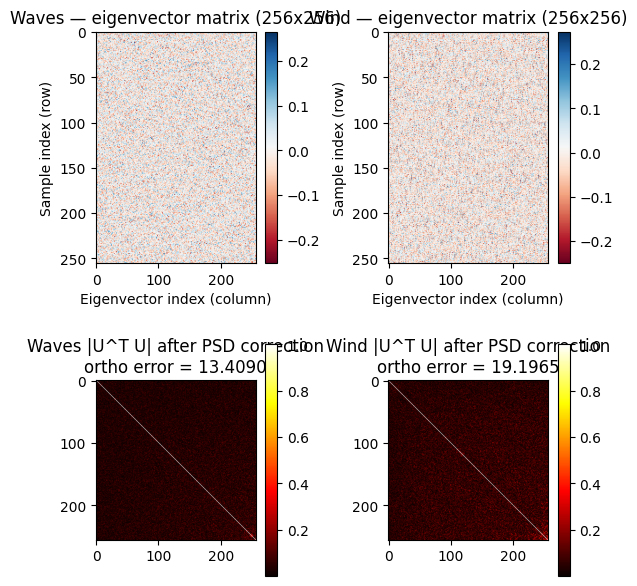


Inital dictionary and frames are ready.


In [ ]:
#=============================================================================================
#                            Dictionary Initialization
#=============================================================================================

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchaudio
import numpy as np
import matplotlib.pyplot as plt
import IPython.display as ipd

# ── Config ────────────────────────────────────────────────────────────────────
M  = 256      # blocklength / frame length
SR = 1024     # sampling rate — M/SR = 0.25 sec per frame
G  = 2        # number of blocks (waves block + wind block)

def build_block_from_audio(audio_path, M, sr):
    """
    Load one audio file, extract sliding window frames of length M
    with hop = M//2, compute the covariance matrix, and return
    the M eigenvectors as columns of an MxM matrix — with PSD
    spectral correction applied to each eigenvector.

    Initialization procedure (PCA + PSD Spectral Correction):
    Step 1: Extract overlapping frames -> stack into data matrix X
    Step 2: Compute covariance C = X^T X / N -> eigendecompose -> get eigenvectors
    Step 3: For each eigenvector, keep its phase but replace its amplitude
            with the average amplitude spectrum of the real audio frames
    Step 4: IFFT back to time domain -> normalize -> store as column

    Returns
    -------
    U_init : np.ndarray, shape (M, M), dtype float32
             Columns are PSD-corrected eigenvectors of the frame covariance matrix.
    frames : np.ndarray, shape (N, M)
             All extracted frames (for training reference).
    """
    # ── Load and preprocess ───────────────────────────────────────────────────
    waveform, orig_sr = torchaudio.load(audio_path)

    # Stereo -> mono by averaging channels
    if waveform.shape[0] > 1:
        waveform = waveform.mean(dim=0, keepdim=True)

    # Resample to target SR if needed
    if orig_sr != sr:
        resampler = torchaudio.transforms.Resample(orig_freq=orig_sr, new_freq=sr)
        waveform  = resampler(waveform)

    # Normalize to [-1, 1]
    peak     = waveform.abs().max() + 1e-8
    waveform = waveform / peak

    audio = waveform.squeeze().numpy().astype(np.float32)  # shape (T,)
    T     = len(audio)
    hop   = M // 2

    print(f"Audio loaded: {T} samples @ {sr} Hz = {T/sr:.2f} sec")

    # ── Step 1: Extract sliding window frames ─────────────────────────────────
    starts = range(0, T - M + 1, hop)
    frames = np.stack([audio[s : s + M] for s in starts], axis=0)  # (N, M)

    # Normalize each frame by its peak amplitude, skip silent frames
    valid_frames = []
    for f in frames:
        peak = np.abs(f).max()
        if peak > 1e-8:
            valid_frames.append(f / peak)
    frames = np.array(valid_frames, dtype=np.float32)
    N = frames.shape[0]

    print(f"Extracted {N} valid frames of length {M} (hop={hop})")

    # ── Step 2: Covariance matrix and eigenvectors ────────────────────────────
    # X: (M, N) — each column is one frame
    X = frames.T                              # (M, N)
    X = X - X.mean(axis=1, keepdims=True)    # mean-center each row

    # C = (1/N) X @ X.T — shape (M, M)
    C = (X @ X.T) / N

    # eigh: numerically stable eigendecomposition for symmetric matrices
    eigenvalues, eigenvectors = np.linalg.eigh(C)
    order        = np.argsort(eigenvalues)[::-1]  # descending eigenvalue order
    eigenvectors = eigenvectors[:, order]          # (M, M) — columns are eigenvectors

    ortho_error = np.linalg.norm(eigenvectors.T @ eigenvectors - np.eye(M))
    print(f"Eigenvector orthogonality error before PSD correction: {ortho_error:.8f}")

    # ── Step 3: PSD Spectral Correction ──────────────────────────────────────
    # Compute average amplitude spectrum from all valid frames
    # avg_amplitude[k] = sqrt( mean over frames of |FFT(frame)[k]|^2 )
    psds = np.array([np.abs(np.fft.rfft(f))**2 for f in frames])  # (N, M//2+1)
    avg_amplitude = np.sqrt(psds.mean(axis=0) + 1e-8)              # (M//2+1,)

    # For each eigenvector: keep phase, replace amplitude with avg_amplitude
    corrected_cols = []
    for i in range(M):
        v    = eigenvectors[:, i]               # i-th eigenvector, shape (M,)
        spec = np.fft.rfft(v)                   # complex spectrum, shape (M//2+1,)
        phase    = np.angle(spec)               # extract phase
        new_spec = avg_amplitude * np.exp(1j * phase)  # replace amplitude, keep phase
        v_corr   = np.fft.irfft(new_spec, n=M).astype(np.float32)  # back to time domain

        # Normalize to unit L2 norm (column convention)
        norm = np.linalg.norm(v_corr)
        v_corr = v_corr / (norm + 1e-8)
        corrected_cols.append(v_corr)

    # Stack corrected eigenvectors as columns -> (M, M)
    U_init = np.stack(corrected_cols, axis=1).astype(np.float32)

    ortho_error_after = np.linalg.norm(U_init.T @ U_init - np.eye(M))
    print(f"Orthogonality error after PSD correction: {ortho_error_after:.6f}")
    print("(expected to increase — training will recover orthogonality)")

    return U_init, frames


# ── Run for waves and wind ─────────────────────────────────────────────────────
print("=" * 50)
print("Building WAVES block...")
U_waves_init, wave_frames = build_block_from_audio(WAVES_PATH, M, SR)

print("\n" + "=" * 50)
print("Building WIND block...")
U_wind_init, wind_frames = build_block_from_audio(WIND_PATH, M, SR)

# ── Sanity plots ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(6, 6))

for ax, U, title in zip(axes[0], [U_waves_init, U_wind_init], ['Waves', 'Wind']):
    im = ax.imshow(U, cmap='RdBu', aspect='auto')
    plt.colorbar(im, ax=ax)
    ax.set_title(f"{title} — eigenvector matrix ({M}x{M})")
    ax.set_xlabel("Eigenvector index (column)")
    ax.set_ylabel("Sample index (row)")

for ax, U, title in zip(axes[1], [U_waves_init, U_wind_init], ['Waves', 'Wind']):
    UtU   = U.T @ U
    error = np.linalg.norm(UtU - np.eye(M))
    im    = ax.imshow(np.abs(UtU), cmap='hot')
    plt.colorbar(im, ax=ax)
    ax.set_title(f"{title} |U^T U| after PSD correction\northo error = {error:.4f}")

plt.tight_layout()
plt.show()

print("\nInital dictionary and frames are ready.")

Using device: cuda
Pretraining classifier on audio frames...
[Classifier] epoch 1/10  acc=0.9322
[Classifier] epoch 5/10  acc=0.9981
[Classifier] epoch 10/10  acc=1.0000
Computing references...

Starting training...
  [Checkpoint saved] epoch 1
[ep   1/300] total=78.8622  covert=24.0308  ortho=548.3043  inter=0.0032  λ_ortho=0.1000
  [Checkpoint saved] epoch 2
  [Checkpoint saved] epoch 3
  [Checkpoint saved] epoch 4
  [Checkpoint saved] epoch 5
  [Checkpoint saved] epoch 6
  [Checkpoint saved] epoch 7
  [Checkpoint saved] epoch 8
  [Checkpoint saved] epoch 9
  [Checkpoint saved] epoch 10
[ep  10/300] total=75.4500  covert=22.6572  ortho=527.9186  inter=0.0031  λ_ortho=0.1000
  [Checkpoint saved] epoch 11
  [Checkpoint saved] epoch 12
  [Checkpoint saved] epoch 13
  [Checkpoint saved] epoch 14
  [Checkpoint saved] epoch 15
  [Checkpoint saved] epoch 16
  [Checkpoint saved] epoch 17
  [Checkpoint saved] epoch 18
  [Checkpoint saved] epoch 19
  [Checkpoint saved] epoch 20
[ep  20/300] to

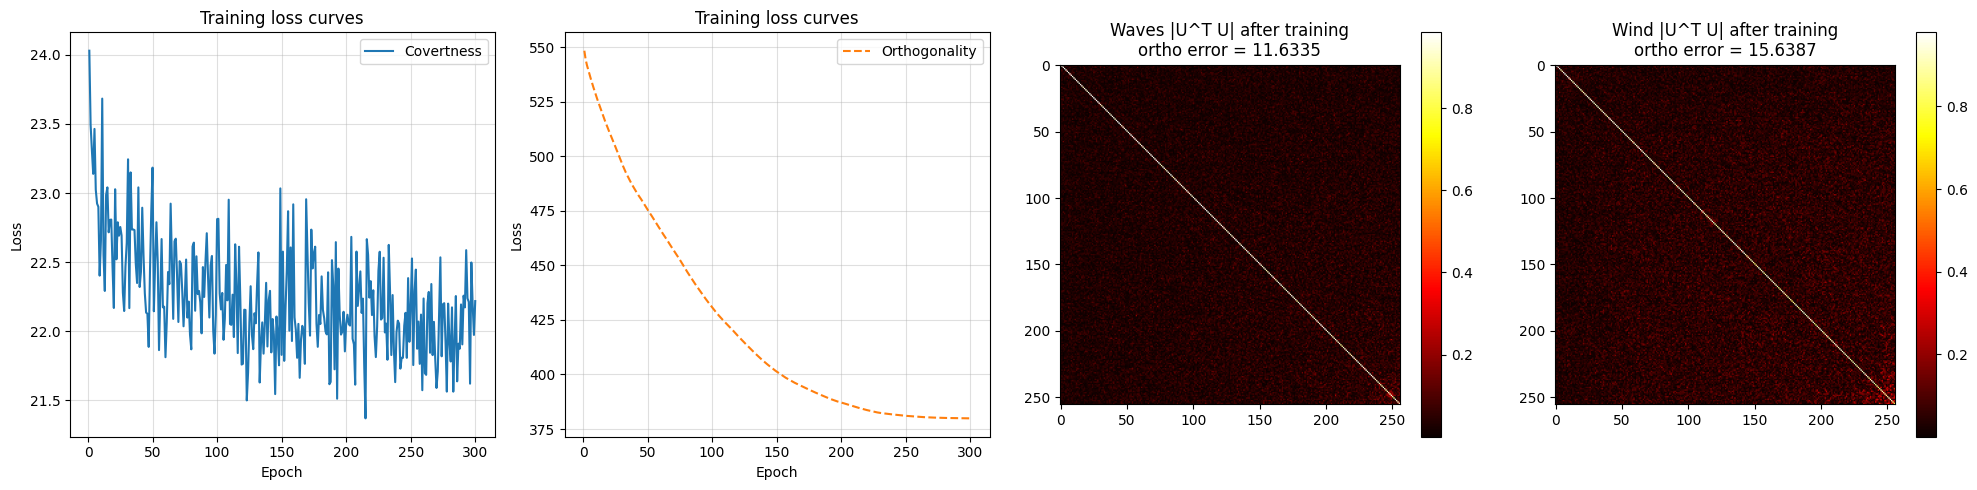

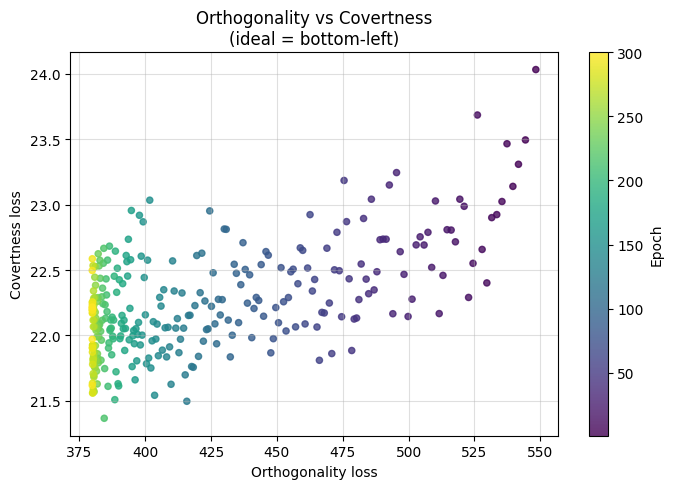

In [ ]:
#=============================================================================================
#                            Dictionary Training
#=============================================================================================

import torch
import torch.nn as nn
import torch.nn.functional as F
import librosa
import random
from tqdm import tqdm

# BOSS dimensions (must match encoder)
M = 256   # dictionary size
G = 2     # number of blocks


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ── Hyperparameters ───────────────────────────────────────────────────────────
LAMBDA_PSD          = 6.0    # PSD matching loss weight
LAMBDA_MEL          = 3.0    # mel spectrogram loss weight
LAMBDA_MSSTFT       = 0.5    # multi-scale STFT loss weight
LAMBDA_CLS          = 2.0    # classifier guidance loss weight
LAMBDA_ORTHO        = 0.1    # fixed orthogonality weight
LAMBDA_INTER        = 0.3    # inter-block orthogonality weight
N_EPOCHS            = 300    # training epochs
BATCH_SIZE          = 16     # codewords per step
LR     = 1e-4   # reduced from 3e-4
LR_MIN = 1e-6   # minimum LR at end of annealing
N_MELS              = 40
N_FFT               = min(128, M)
HOP_LENGTH          = N_FFT // 4

# BOSS encoder layer structure for codeword sampling
K1, K2 = 1, 1
A1 = [1.0]   # Layer 1 alphabet
A2 = [-1.0]   # Layer 2 alphabet — disjoint from A1
M2 = 2 ** int(np.floor(np.log2(M - K1)))  # candidate set size for layer 2 = 128


# ── Mel extractor ─────────────────────────────────────────────────────────────
class LogMelExtractor(nn.Module):
    def __init__(self, sr, n_fft, hop_length, n_mels):
        super().__init__()
        self.n_fft      = n_fft
        self.hop_length = hop_length
        mel_fb = librosa.filters.mel(sr=sr, n_fft=n_fft, n_mels=n_mels)
        self.register_buffer('mel_filter', torch.tensor(mel_fb, dtype=torch.float32))
        self.register_buffer('window',     torch.hann_window(n_fft))

    def forward(self, x):
        spec  = torch.stft(
            x, n_fft=self.n_fft, hop_length=self.hop_length,
            win_length=self.n_fft, window=self.window,
            return_complex=True, center=True, pad_mode='reflect'
        )
        power = spec.abs() ** 2
        mel   = torch.matmul(self.mel_filter, power)
        return torch.log(mel + 1e-6)

mel_extractor = LogMelExtractor(SR, N_FFT, HOP_LENGTH, N_MELS).to(device)


# ── Classifier (wave=0, wind=1) ───────────────────────────────────────────────
class AudioClassifier(nn.Module):
    def __init__(self, n_mels):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.AdaptiveAvgPool2d((4, 4)),
        )
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 4 * 4, 64), nn.ReLU(),
            nn.Linear(64, 2),
        )

    def forward(self, logmel):
        return self.fc(self.net(logmel.unsqueeze(1)))


def pretrain_classifier(wave_frames, wind_frames, mel_extractor, epochs=10, lr=1e-3):
    """
    Pretrain classifier on sliding window frames extracted from the audio files.
    wave_frames and wind_frames from Cell 2 serve as the training data —
    each frame is an M-length slice of real audio, which is enough to distinguish
    the two classes spectrally.
    """
    clf = AudioClassifier(N_MELS).to(device)
    opt = torch.optim.Adam(clf.parameters(), lr=lr)

    wave_t = torch.tensor(wave_frames, dtype=torch.float32)
    wind_t = torch.tensor(wind_frames, dtype=torch.float32)
    X_all  = torch.cat([wave_t, wind_t], dim=0).to(device)
    y_all  = torch.cat([
        torch.zeros(len(wave_t), dtype=torch.long),
        torch.ones(len(wind_t),  dtype=torch.long)
    ], dim=0).to(device)

    n = len(X_all)
    for ep in range(epochs):
        perm    = torch.randperm(n)
        correct = 0
        for i in range(0, n, BATCH_SIZE):
            idx    = perm[i:i+BATCH_SIZE]
            audio  = X_all[idx]
            labels = y_all[idx]
            logmel = mel_extractor(audio)
            logits = clf(logmel)
            loss   = F.cross_entropy(logits, labels)
            opt.zero_grad(); loss.backward(); opt.step()
            correct += (logits.argmax(1) == labels).sum().item()
        if (ep + 1) % 5 == 0 or ep == 0:
            print(f"[Classifier] epoch {ep+1}/{epochs}  acc={correct/n:.4f}")

    clf.eval()
    for p in clf.parameters():
        p.requires_grad_(False)
    return clf

print("Pretraining classifier on audio frames...")
classifier = pretrain_classifier(wave_frames, wind_frames, mel_extractor)


# ── Pre-compute reference mel spectrograms and mean PSD ───────────────────────
@torch.no_grad()
def compute_references(frames, mel_extractor, max_refs=50):
    """Store up to max_refs mel spectrograms from real frames as training targets."""
    tensor = torch.tensor(frames, dtype=torch.float32).to(device)
    refs   = []
    for i in range(min(max_refs, len(frames))):
        mel = mel_extractor(tensor[i].unsqueeze(0)).squeeze(0)
        refs.append(mel.cpu())
    return refs

def compute_mean_psd(frames):
    """Pre-compute average PSD from real audio frames — fixed training target."""
    psds = np.array([np.abs(np.fft.rfft(f))**2 for f in frames])
    return torch.tensor(psds.mean(axis=0), dtype=torch.float32)

print("Computing references...")
refs_waves   = compute_references(wave_frames, mel_extractor)
refs_wind    = compute_references(wind_frames, mel_extractor)
mean_psd_waves = compute_mean_psd(wave_frames).to(device)
mean_psd_wind  = compute_mean_psd(wind_frames).to(device)


# ── Loss functions ────────────────────────────────────────────────────────────
def psd_loss_fixed(codewords, target_psd):
    """Log-L1 loss between codeword PSD and pre-computed mean PSD target."""
    psd_cw  = torch.fft.rfft(codewords, dim=-1).abs() ** 2
    log_cw  = torch.log(psd_cw  + 1e-8)
    log_tgt = torch.log(target_psd + 1e-8).unsqueeze(0).expand_as(log_cw)
    return F.l1_loss(log_cw, log_tgt)

def mel_loss(codewords, ref_frames, mel_extractor):
    """L1 distance between log-mel spectrograms of codewords and reference frames."""
    mel_c = mel_extractor(codewords)
    mel_r = mel_extractor(ref_frames)
    T     = min(mel_c.shape[-1], mel_r.shape[-1])
    return F.l1_loss(mel_c[:, :, :T], mel_r[:, :, :T])

class MultiScaleSTFTLoss(nn.Module):
    """Spectral consistency loss at multiple FFT resolutions."""
    def __init__(self, fft_sizes=(32, 64, 128, 256)):
        super().__init__()
        self.fft_sizes = fft_sizes
        self.hop_sizes = [s // 4 for s in fft_sizes]

    def forward(self, x, y):
        if x.dim() == 1: x = x.unsqueeze(0)
        if y.dim() == 1: y = y.unsqueeze(0)
        loss = 0.0
        for n_fft, hop in zip(self.fft_sizes, self.hop_sizes):
            win = torch.hann_window(n_fft, device=x.device)
            X = torch.stft(x, n_fft=n_fft, hop_length=hop, win_length=n_fft,
                           window=win, return_complex=True,
                           center=True, pad_mode='reflect').abs() + 1e-7
            Y = torch.stft(y, n_fft=n_fft, hop_length=hop, win_length=n_fft,
                           window=win, return_complex=True,
                           center=True, pad_mode='reflect').abs() + 1e-7
            loss += F.l1_loss(torch.log(X), torch.log(Y))
            loss += torch.norm(Y - X, 'fro') / (torch.norm(Y, 'fro') + 1e-8)
        return loss / len(self.fft_sizes)

msstft_fn = MultiScaleSTFTLoss().to(device)

def intra_ortho_loss(U):
    """||U^T U - I||^2_F — columns should be orthonormal."""
    UtU = U.T @ U
    return torch.norm(UtU - torch.eye(M, device=U.device)) ** 2

def inter_ortho_loss(U1, U2):
    """||U1^T U2||^2_F — two blocks should be orthogonal to each other."""
    cross = U1.T @ U2
    return (cross ** 2).mean()


# ── Codeword sampling ─────────────────────────────────────────────────────────
def sample_codewords_cols(U, batch_size, device):
    """
    Sample BOSS codewords from dictionary matrix U (columns = basis vectors).
    Follows two-layer structure with disjoint supports and disjoint alphabets.

    Layer 1: K1 columns from M(1) = [M], values from A1
    Layer 2: K2 columns from M(2) = [M] \\ I1, restricted to M2, values from A2
    Codeword = sum of K1+K2 scaled columns, normalized to unit peak amplitude.
    """
    A1_t = torch.tensor(A1, dtype=torch.float32, device=device)
    A2_t = torch.tensor(A2, dtype=torch.float32, device=device)
    codewords = []

    for _ in range(batch_size):
        perm = torch.randperm(M, device=device)

        # Layer 1: pick K1 columns
        idx1 = perm[:K1]
        val1 = A1_t[torch.randint(len(A1_t), (K1,), device=device)]
        c    = (U[:, idx1] * val1.unsqueeze(0)).sum(dim=1)  # (M,)

        # Layer 2: pick K2 from remaining, restricted to M2
        remaining   = perm[K1:]
        candidates2 = remaining[:M2]
        sel2        = torch.randperm(M2, device=device)[:K2]
        idx2        = candidates2[sel2]
        val2        = A2_t[torch.randint(len(A2_t), (K2,), device=device)]
        c           = c + (U[:, idx2] * val2.unsqueeze(0)).sum(dim=1)

        # Normalize to unit peak amplitude
        c = c / (c.abs().max() + 1e-8) * 0.95
        codewords.append(c)

    return torch.stack(codewords, dim=0)  # (batch_size, M)


# ── Block model ───────────────────────────────────────────────────────────────
class BOSSBlockPair(nn.Module):
    """Two learnable MxM dictionary blocks stored in column convention."""
    def __init__(self, U_waves_init, U_wind_init):
        super().__init__()
        self.U_waves = nn.Parameter(torch.tensor(U_waves_init))
        self.U_wind  = nn.Parameter(torch.tensor(U_wind_init))

    def get_blocks(self):
        return self.U_waves, self.U_wind


# ── Training loop ─────────────────────────────────────────────────────────────
def train_blocks(U_waves_init, U_wind_init, wave_frames, wind_frames,
                 mel_extractor, classifier):
    model     = BOSSBlockPair(U_waves_init, U_wind_init).to(device)
    opt       = torch.optim.Adam(model.parameters(), lr=LR)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(opt, N_EPOCHS, eta_min=LR_MIN)

    wave_tensor = torch.tensor(wave_frames, dtype=torch.float32).to(device)
    wind_tensor = torch.tensor(wind_frames, dtype=torch.float32).to(device)

    history = []
    checkpoints = []

    for epoch in range(N_EPOCHS):
        model.train()
        U_waves, U_wind = model.get_blocks()



        # ── Sample codewords ──────────────────────────────────────────────────
        cw_waves = sample_codewords_cols(U_waves, BATCH_SIZE, device)  # (B, M)
        cw_wind  = sample_codewords_cols(U_wind,  BATCH_SIZE, device)  # (B, M)

        # ── Sample reference frames ───────────────────────────────────────────
        ri_v = torch.randint(0, len(wave_tensor), (BATCH_SIZE,))
        ri_w = torch.randint(0, len(wind_tensor), (BATCH_SIZE,))
        ref_waves = wave_tensor[ri_v]
        ref_wind  = wind_tensor[ri_w]

        # ── Loss 1: PSD (fixed mean target) ───────────────────────────────────
        l_psd = (psd_loss_fixed(cw_waves, mean_psd_waves) +
                 psd_loss_fixed(cw_wind,  mean_psd_wind))

        # ── Loss 2: Mel spectrogram ───────────────────────────────────────────
        mel_cw_waves = mel_extractor(cw_waves)
        mel_cw_wind  = mel_extractor(cw_wind)
        ref_mel_waves = torch.stack(
            random.choices(refs_waves, k=BATCH_SIZE), dim=0
        ).to(device)
        ref_mel_wind = torch.stack(
            random.choices(refs_wind, k=BATCH_SIZE), dim=0
        ).to(device)
        T_v = min(mel_cw_waves.shape[-1], ref_mel_waves.shape[-1])
        T_w = min(mel_cw_wind.shape[-1],  ref_mel_wind.shape[-1])
        l_mel = (F.l1_loss(mel_cw_waves[:, :, :T_v], ref_mel_waves[:, :, :T_v]) +
                 F.l1_loss(mel_cw_wind[:,  :, :T_w], ref_mel_wind[:,  :, :T_w]))

        # ── Loss 3: Multi-scale STFT ──────────────────────────────────────────
        half = BATCH_SIZE // 2
        l_msstft = (msstft_fn(cw_waves[:half], cw_waves[half:]) +
                    msstft_fn(cw_wind[:half],  cw_wind[half:])
                    ).clamp(max=10.0)

        # ── Loss 4: Classifier guidance ───────────────────────────────────────
        tgt_waves = torch.zeros(BATCH_SIZE, dtype=torch.long, device=device)
        tgt_wind  = torch.ones( BATCH_SIZE, dtype=torch.long, device=device)
        l_cls = (F.cross_entropy(classifier(mel_cw_waves), tgt_waves) +
                 F.cross_entropy(classifier(mel_cw_wind),  tgt_wind))

        # ── Loss 5: Orthogonality (intra + inter) ─────────────────────────────
        l_ortho = intra_ortho_loss(U_waves) + intra_ortho_loss(U_wind)
        l_inter = inter_ortho_loss(U_waves, U_wind)

        # ── Total loss ────────────────────────────────────────────────────────
        covert_loss = (LAMBDA_PSD    * l_psd    +
                       LAMBDA_MEL    * l_mel    +
                       LAMBDA_MSSTFT * l_msstft +
                       LAMBDA_CLS    * l_cls)
        total_loss  = covert_loss + LAMBDA_ORTHO * l_ortho + LAMBDA_INTER * l_inter

        opt.zero_grad()
        total_loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        opt.step()
        scheduler.step()

# ── Save checkpoint every 10 epochs ──────────────────────────────────
        if (epoch + 1) % 1 == 0:
            checkpoint = {
                'epoch':   epoch + 1,
                'U_waves': model.U_waves.detach().cpu().numpy(),
                'U_wind':  model.U_wind.detach().cpu().numpy(),
            }
            checkpoints.append(checkpoint)
            print(f"  [Checkpoint saved] epoch {epoch + 1}")

        history.append({
            'epoch':   epoch + 1,
            'total':   total_loss.item(),
            'covert':  covert_loss.item(),
            'ortho':   l_ortho.item(),
            'inter':   l_inter.item(),
            'psd':     l_psd.item(),
            'mel':     l_mel.item(),
            'msstft':  l_msstft.item(),
            'cls':     l_cls.item(),
            'LAMBDA_ORTHO': LAMBDA_ORTHO,
        })

        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f"[ep {epoch+1:3d}/{N_EPOCHS}] "
                  f"total={total_loss.item():.4f}  "
                  f"covert={covert_loss.item():.4f}  "
                  f"ortho={l_ortho.item():.4f}  "
                  f"inter={l_inter.item():.4f}  "
                  f"λ_ortho={LAMBDA_ORTHO:.4f}")

    # Extract trained matrices
    model.eval()
    with torch.no_grad():
        U_waves_trained = model.U_waves.cpu().numpy()
        U_wind_trained  = model.U_wind.cpu().numpy()

    return U_waves_trained, U_wind_trained, history, checkpoints


# ── Run training ──────────────────────────────────────────────────────────────
print("\nStarting training...")
U_waves_trained, U_wind_trained, history, checkpoints = train_blocks(
    U_waves_init, U_wind_init,
    wave_frames, wind_frames,
    mel_extractor, classifier
)

# ── Save trained matrices ─────────────────────────────────────────────────────
os.makedirs("/content/outputs", exist_ok=True)
np.save("/content/outputs/U_waves_trained.npy", U_waves_trained)
np.save("/content/outputs/U_wind_trained.npy",  U_wind_trained)
print("Saved trained matrices to /content/outputs/")

# ── Plotting ──────────────────────────────────────────────────────────────────
epochs = [h['epoch']  for h in history]
covert = [h['covert'] for h in history]
ortho  = [h['ortho']  for h in history]

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

ax = axes[0]
ax.plot(epochs, covert, label='Covertness', lw=1.5, color='tab:blue')
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.set_title('Training loss curves')
ax.legend(); ax.grid(True, alpha=0.4)

ax = axes[1]
ax.plot(epochs, ortho,  label='Orthogonality', lw=1.5, color='tab:orange', linestyle='--')
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.set_title('Training loss curves')
ax.legend(); ax.grid(True, alpha=0.4)

for ax, U, title in zip(axes[2:],
                         [U_waves_trained, U_wind_trained],
                         ['Waves', 'Wind']):
    UtU   = U.T @ U
    error = np.linalg.norm(UtU - np.eye(M))
    im    = ax.imshow(np.abs(UtU), cmap='hot')
    plt.colorbar(im, ax=ax)
    ax.set_title(f"{title} |U^T U| after training\northo error = {error:.4f}")

plt.tight_layout()
plt.show()

# Pareto scatter
plt.figure(figsize=(7, 5))
sc = plt.scatter(ortho, covert, c=epochs, cmap='viridis', s=20, alpha=0.8)
plt.colorbar(sc, label='Epoch')
plt.xlabel('Orthogonality loss')
plt.ylabel('Covertness loss')
plt.title('Orthogonality vs Covertness\n(ideal = bottom-left)')
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np

# ── Pareto front + best epoch 선택 ───────────────────────────────────────────
ortho_vals  = np.array([h['ortho']  for h in history])
covert_vals = np.array([h['covert'] for h in history])
epochs_arr  = np.array([h['epoch']  for h in history])

# Pareto front: 두 지표 모두 더 좋은 점이 없는 점들
def get_pareto_front(ortho, covert):
    pareto_mask = np.ones(len(ortho), dtype=bool)
    for i in range(len(ortho)):
        for j in range(len(ortho)):
            if i == j: continue
            if ortho[j] <= ortho[i] and covert[j] <= covert[i] and \
               (ortho[j] < ortho[i] or covert[j] < covert[i]):
                pareto_mask[i] = False
                break
    return pareto_mask

pareto_mask = get_pareto_front(ortho_vals, covert_vals)

p_epochs  = epochs_arr[pareto_mask]
p_ortho   = ortho_vals[pareto_mask]
p_covert  = covert_vals[pareto_mask]

# 정규화 후 원점까지 거리 기준으로 best 선택
o_norm = (p_ortho  - ortho_vals.min())  / (ortho_vals.max()  - ortho_vals.min())
c_norm = (p_covert - covert_vals.min()) / (covert_vals.max() - covert_vals.min())
dist   = np.sqrt(o_norm**2 + c_norm**2)

best_idx   = np.argmin(dist)
best_epoch = p_epochs[best_idx]

print(f"Pareto front 점 수: {pareto_mask.sum()}")
print(f"\n[Best epoch] {best_epoch}")
print(f"  ortho  = {p_ortho[best_idx]:.4f}")
print(f"  covert = {p_covert[best_idx]:.4f}")

# Pareto front 전체 출력
print(f"\nPareto front 전체 (ortho 오름차순):")
sort_idx = np.argsort(p_ortho)
for i in sort_idx:
    marker = " ← best" if p_epochs[i] == best_epoch else ""
    print(f"  epoch {p_epochs[i]:3d}  ortho={p_ortho[i]:.4f}  covert={p_covert[i]:.4f}{marker}")


Pareto front 점 수: 5

[Best epoch] 215
  ortho  = 384.4767
  covert = 21.3675

Pareto front 전체 (ortho 오름차순):
  epoch 300  ortho=379.9124  covert=22.2169
  epoch 299  ortho=379.9179  covert=21.9717
  epoch 296  ortho=379.9370  covert=21.6188
  epoch 283  ortho=380.0621  covert=21.5609
  epoch 215  ortho=384.4767  covert=21.3675 ← best


In [ ]:
best1_matrix = next(c for c in checkpoints if c['epoch'] == best_epoch)


In [ ]:
#=============================================================================================
#                            Encoder/Decoder Setup for Pareto Simulation
#=============================================================================================

import numpy as np

CRC_POLY   = [1, 0, 1, 1]   # CRC-3
CRC_DEGREE = len(CRC_POLY) - 1
LIST_SIZE  = 4
EBNO_FIXED = 3.0             # fixed Eb/N0 for Pareto simulation (dB)

# Verify bit budget
_enc_test = BOSSEncoderStandalone(
    M=256, G=2, L=2,
    sparsity_levels=[1, 1],
    alphabets=[[1.0], [-1.0]]
)
B_total = _enc_test.B
B_info  = B_total - CRC_DEGREE
print(f"B={B_total}, B_info={B_info}, rate={B_total/256:.4f}")

# ── Build encoders ─────────────────────────────────────────────────────────
# Encoder 0:  initial dictionary (U_waves_init, U_wind_init)


all_dicts = [{'epoch': 0,
              'U_waves': U_waves_init,
              'U_wind':  U_wind_init}] + checkpoints

print(f"Got {len(all_dicts)}\n")

encoders = []
for d in all_dicts:
    enc = BOSSEncoderStandalone(
        M=256, G=2, L=2,
        sparsity_levels=[1, 1],
        alphabets=[[1.0], [-1.0]],
        A_list=[d['U_waves'], d['U_wind']]
    )
    encoders.append((d['epoch'], enc, d['U_waves'], d['U_wind']))

print(f"\n{len(encoders)} encoders ready:")
for epoch, enc, _, _ in encoders:
    label = "initial" if epoch == 0 else f"epoch {epoch}"
    print(f"  [{label}] B={enc.B}")

B=16, B_info=13, rate=0.0625
Got 301


301 encoders ready:
  [initial] B=16
  [epoch 1] B=16
  [epoch 2] B=16
  [epoch 3] B=16
  [epoch 4] B=16
  [epoch 5] B=16
  [epoch 6] B=16
  [epoch 7] B=16
  [epoch 8] B=16
  [epoch 9] B=16
  [epoch 10] B=16
  [epoch 11] B=16
  [epoch 12] B=16
  [epoch 13] B=16
  [epoch 14] B=16
  [epoch 15] B=16
  [epoch 16] B=16
  [epoch 17] B=16
  [epoch 18] B=16
  [epoch 19] B=16
  [epoch 20] B=16
  [epoch 21] B=16
  [epoch 22] B=16
  [epoch 23] B=16
  [epoch 24] B=16
  [epoch 25] B=16
  [epoch 26] B=16
  [epoch 27] B=16
  [epoch 28] B=16
  [epoch 29] B=16
  [epoch 30] B=16
  [epoch 31] B=16
  [epoch 32] B=16
  [epoch 33] B=16
  [epoch 34] B=16
  [epoch 35] B=16
  [epoch 36] B=16
  [epoch 37] B=16
  [epoch 38] B=16
  [epoch 39] B=16
  [epoch 40] B=16
  [epoch 41] B=16
  [epoch 42] B=16
  [epoch 43] B=16
  [epoch 44] B=16
  [epoch 45] B=16
  [epoch 46] B=16
  [epoch 47] B=16
  [epoch 48] B=16
  [epoch 49] B=16
  [epoch 50] B=16
  [epoch 51] B=16
  [epoch 52] B=


Listening to Waves codewords (sr=1024 Hz)


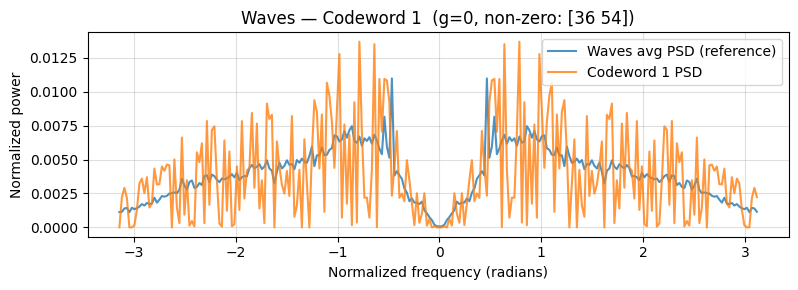

  Codeword 1 (g=0, non-zero indices: [36 54]):


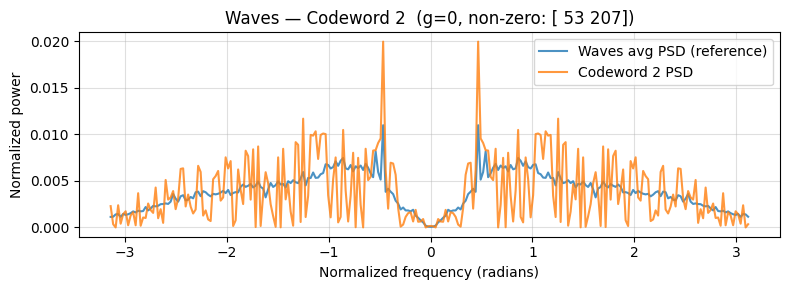

  Codeword 2 (g=0, non-zero indices: [ 53 207]):


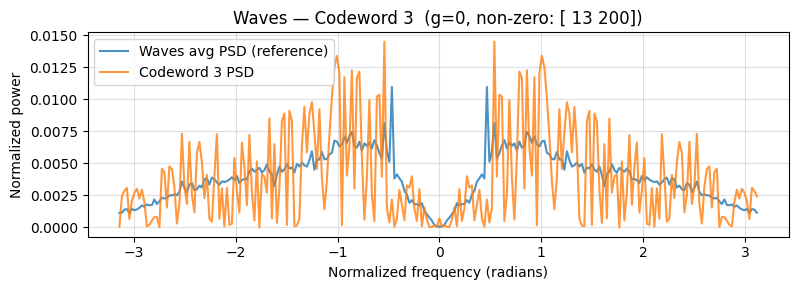

  Codeword 3 (g=0, non-zero indices: [ 13 200]):


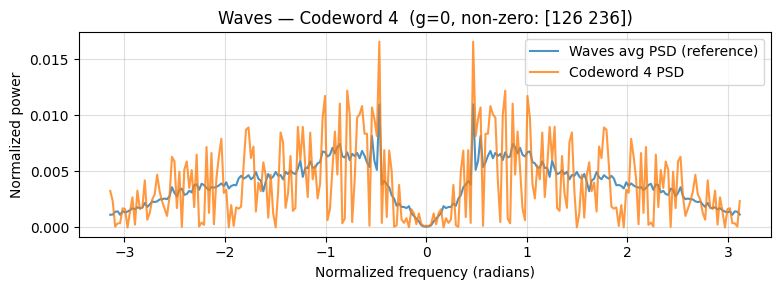

  Codeword 4 (g=0, non-zero indices: [126 236]):



  Concatenation of 4 codewords (4 × 0.25s = 1.00s total):



Listening to Wind codewords (sr=1024 Hz)


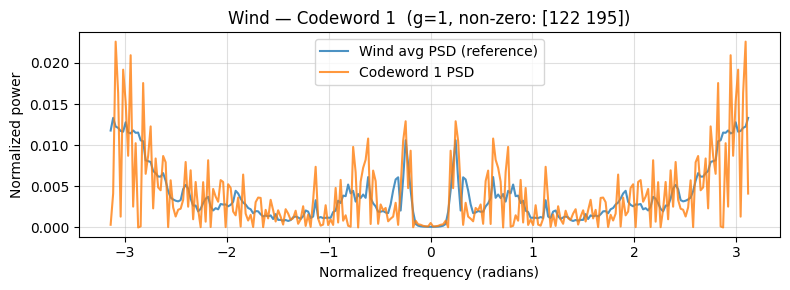

  Codeword 1 (g=1, non-zero indices: [122 195]):


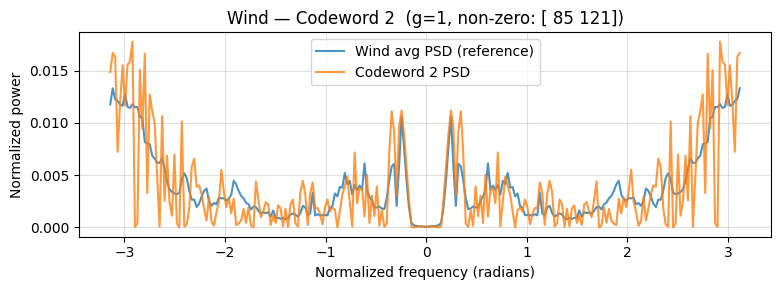

  Codeword 2 (g=1, non-zero indices: [ 85 121]):


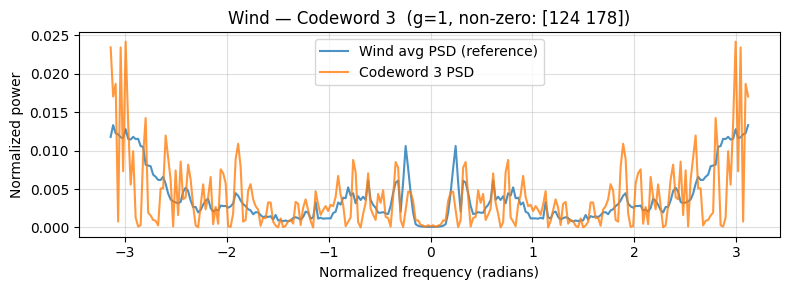

  Codeword 3 (g=1, non-zero indices: [124 178]):


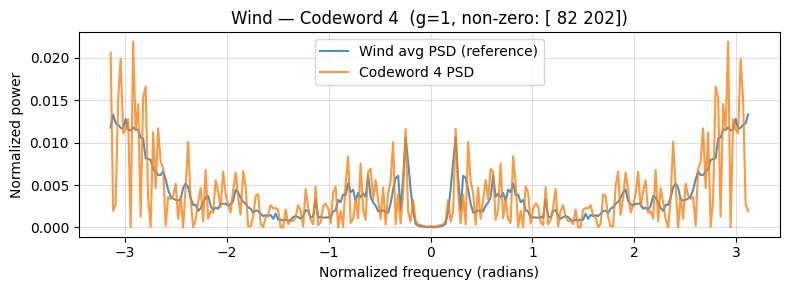

  Codeword 4 (g=1, non-zero indices: [ 82 202]):



  Concatenation of 4 codewords (4 × 0.25s = 1.00s total):


In [ ]:


encoder_trained = BOSSEncoderStandalone(
    M=256, G=2, L=2,
    sparsity_levels=[1, 1],
    alphabets=[[1.0], [-1.0]],
    A_list=[U_waves_trained, U_wind_trained]
)

# ── Pre-compute reference average PSDs ───────────────────────────────────────
def compute_avg_psd(frames):
    """
    Compute average PSD across all frames.
    frames : np.ndarray, shape (N, M)
    returns : np.ndarray, shape (M,) — averaged and fftshifted PSD
    """
    psds = np.abs(np.fft.fft(frames, axis=1)) ** 2   # (N, M)
    return np.fft.fftshift(psds.mean(axis=0))         # (M,) — averaged, shifted

avg_psd_waves = compute_avg_psd(wave_frames)
avg_psd_wind  = compute_avg_psd(wind_frames)

# Normalized frequency axis — -pi to pi
omega = np.linspace(-np.pi, np.pi, M, endpoint=False)


# ── Listen to codewords + PSD plots ──────────────────────────────────────────
def listen_to_codewords(encoder, block_name, sr, avg_psd_ref, n_random=4):
    """
    Generate n_random codewords using the trained encoder, play each one,
    and show a PSD comparison plot for each.
    Block index is inferred from block_name: 'Waves' -> g=0, 'Wind' -> g=1.
    """
    print(f"\n{'='*50}")
    print(f"Listening to {block_name} codewords (sr={sr} Hz)")
    print(f"{'='*50}")

    playback_sr = 16000
    target      = int(M * playback_sr / SR)

    block_bit = 0 if block_name.lower() == 'waves' else 1
    B         = encoder.B
    B_0       = int(np.floor(np.log2(encoder.G)))

    upsampled_cws = []

    for i in range(n_random):
        # Build bit source
        block_bits  = np.array([block_bit] * B_0, dtype=np.float32)
        random_bits = np.random.randint(0, 2, size=B - B_0).astype(np.float32)
        bits        = np.concatenate([block_bits, random_bits])

        # Encode
        c, g, x_g = encoder.encode(bits)   # c: shape (M,)

        # PSD of this codeword — fftshift for -pi to pi
        psd_cw = np.fft.fftshift(np.abs(np.fft.fft(c)) ** 2)

        # Normalize both PSDs to compare shape not energy
        psd_cw_norm  = psd_cw  / (psd_cw.sum()  + 1e-8)
        psd_ref_norm = avg_psd_ref / (avg_psd_ref.sum() + 1e-8)

        # Plot
        plt.figure(figsize=(8, 3))
        plt.plot(omega, psd_ref_norm, label=f'{block_name} avg PSD (reference)',
                 color='tab:blue', lw=1.5, alpha=0.8)
        plt.plot(omega, psd_cw_norm,  label=f'Codeword {i+1} PSD',
                 color='tab:orange', lw=1.5, alpha=0.8)
        plt.xlabel('Normalized frequency (radians)')
        plt.ylabel('Normalized power')
        plt.title(f'{block_name} — Codeword {i+1}  '
                  f'(g={g}, non-zero: {np.where(x_g != 0)[0]})')
        plt.legend()
        plt.grid(True, alpha=0.4)
        plt.tight_layout()
        plt.show()

        # Upsample for playback
        c_t       = torch.tensor(c, dtype=torch.float32).unsqueeze(0).unsqueeze(0)
        upsampled = F.interpolate(c_t, size=target, mode='linear',
                                  align_corners=False).squeeze()
        audio     = upsampled / (upsampled.abs().max() + 1e-8)
        upsampled_cws.append(upsampled)

        print(f"  Codeword {i+1} (g={g}, non-zero indices: {np.where(x_g != 0)[0]}):")
        ipd.display(ipd.Audio(audio.numpy(), rate=playback_sr))

    # Concatenation
    concat_audio = torch.cat(upsampled_cws, dim=0)
    concat_audio = concat_audio / (concat_audio.abs().max() + 1e-8)
    print(f"\n  Concatenation of {n_random} codewords "
          f"({n_random} × {M/SR:.2f}s = {n_random * M/SR:.2f}s total):")
    ipd.display(ipd.Audio(concat_audio.numpy(), rate=playback_sr))


listen_to_codewords(encoder_trained, "Waves", SR, avg_psd_waves)
listen_to_codewords(encoder_trained, "Wind",  SR, avg_psd_wind)


Listening to Waves codewords (sr=1024 Hz)


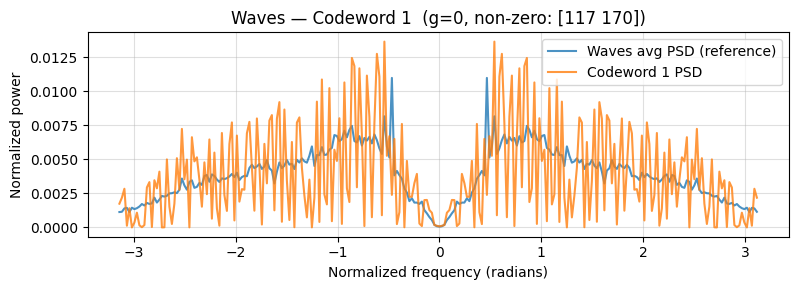

  Codeword 1 (g=0, non-zero indices: [117 170]):


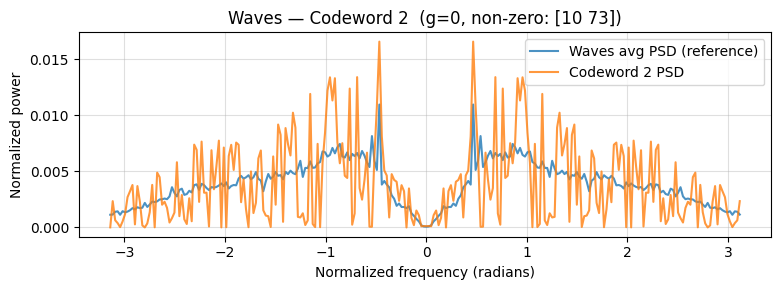

  Codeword 2 (g=0, non-zero indices: [10 73]):


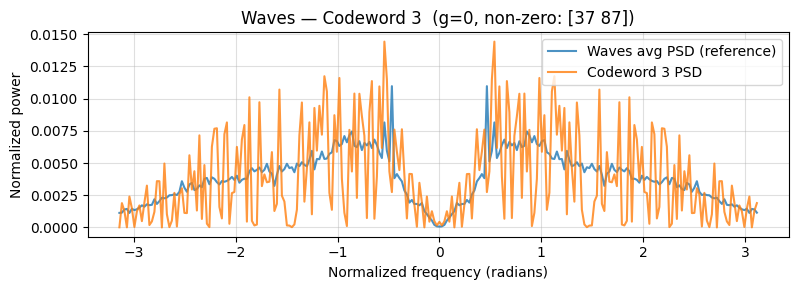

  Codeword 3 (g=0, non-zero indices: [37 87]):


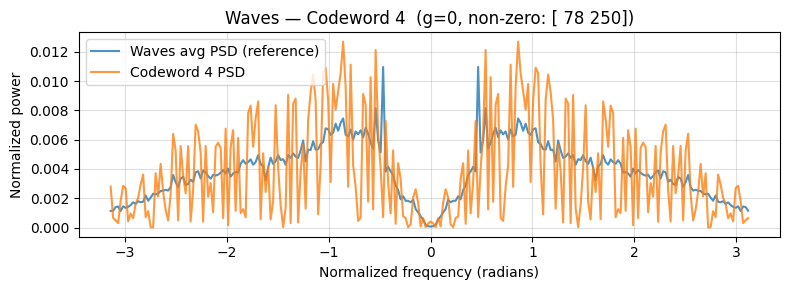

  Codeword 4 (g=0, non-zero indices: [ 78 250]):



  Concatenation of 4 codewords (4 × 0.25s = 1.00s total):



Listening to Wind codewords (sr=1024 Hz)


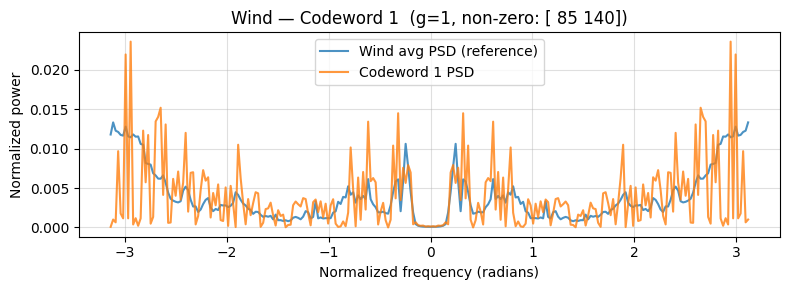

  Codeword 1 (g=1, non-zero indices: [ 85 140]):


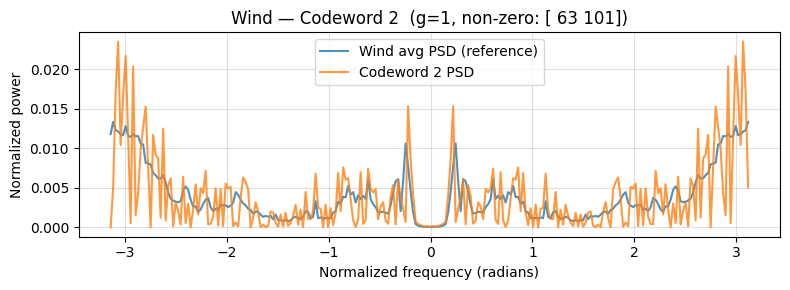

  Codeword 2 (g=1, non-zero indices: [ 63 101]):


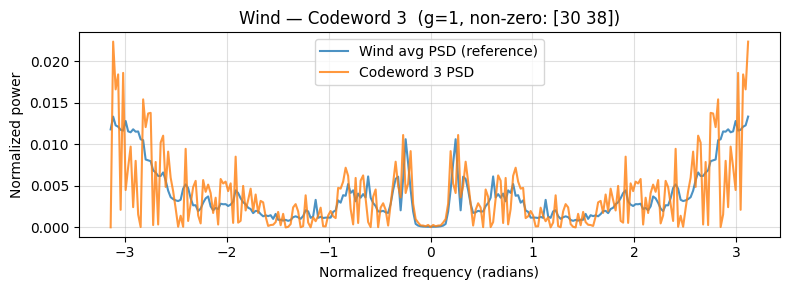

  Codeword 3 (g=1, non-zero indices: [30 38]):


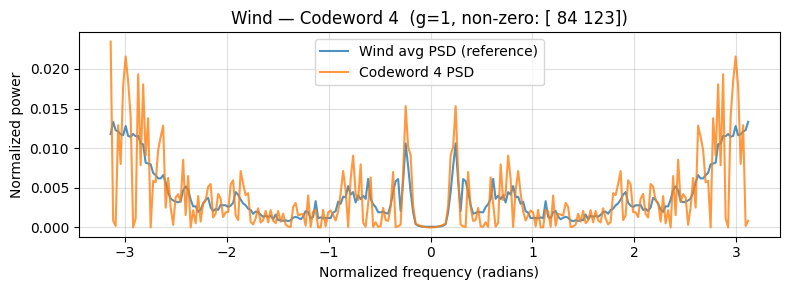

  Codeword 4 (g=1, non-zero indices: [ 84 123]):



  Concatenation of 4 codewords (4 × 0.25s = 1.00s total):


In [ ]:
avg_psd_waves = compute_avg_psd(wave_frames)
avg_psd_wind  = compute_avg_psd(wind_frames)

# Normalized frequency axis — -pi to pi
omega = np.linspace(-np.pi, np.pi, M, endpoint=False)

encoder_trained_best1 = BOSSEncoderStandalone(
    M=256, G=2, L=2,
    sparsity_levels=[1, 1],
    alphabets=[[1.0], [-1.0]],
    A_list=[best1_matrix['U_waves'], best1_matrix['U_wind']]
)

listen_to_codewords(encoder_trained_best1, "Waves", SR, avg_psd_waves)
listen_to_codewords(encoder_trained_best1, "Wind",  SR, avg_psd_wind)

Waves codeword PSD distance distribution (n=256):
  Mean     = 0.048644
  Std      = 0.003142
  Mean + 1σ = 0.051786
  Mean + 2σ = 0.054929
  Mean + 3σ = 0.058071

Wind codeword PSD distance distribution (n=256):
  Mean     = 0.056185
  Std      = 0.004818
  Mean + 1σ = 0.061003
  Mean + 2σ = 0.065821
  Mean + 3σ = 0.070639


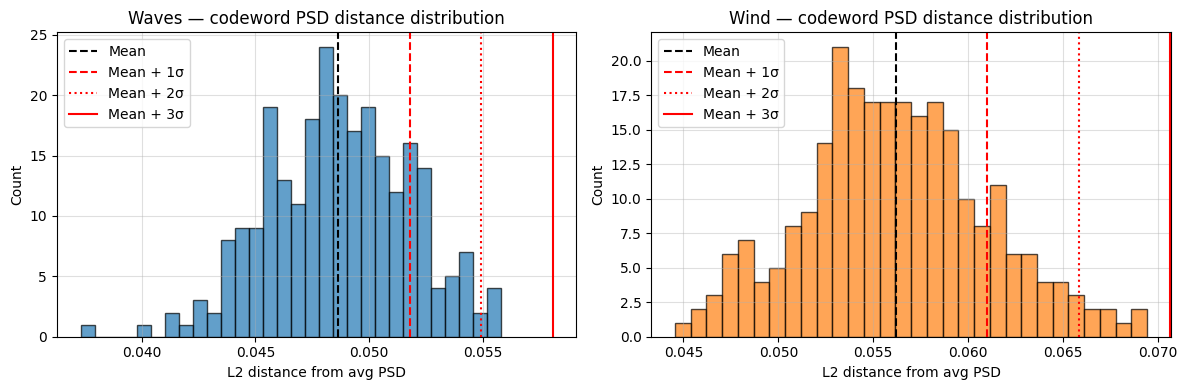


Set thresholds manually below based on distributions above.

Threshold (Waves): 0.054929
Threshold (Wind):  0.065821


In [ ]:
#=============================================================================================
#                            PI Threshold Calculation (Codeword-based)
#=============================================================================================
# Generate actual codewords from the final trained encoder,
# compute L2 distance between each codeword's normalized PSD
# and the average PSD of the corresponding real audio block.
# Get mean and std of those distances for waves and wind separately.

N_CALIBRATION = 256   # number of codewords per block for calibration

def compute_codeword_psd_distances(encoder, avg_psd_ref, block_index,
                                    n_samples=N_CALIBRATION):
    """
    Generate n_samples codewords from a specific block (g=block_index),
    compute L2 distance between each codeword's normalized PSD
    and the normalized average PSD reference.

    Parameters
    ----------
    encoder      : BOSSEncoderStandalone
    avg_psd_ref  : np.ndarray, shape (M,) — fftshifted avg PSD from real frames
    block_index  : int — 0 for waves, 1 for wind
    n_samples    : int — number of codewords to generate

    Returns
    -------
    distances : np.ndarray, shape (n_samples,)
    """
    B_0      = int(np.floor(np.log2(encoder.G)))
    distances = []

    psd_ref_norm = avg_psd_ref / (avg_psd_ref.sum() + 1e-8)

    for _ in range(n_samples):
        # Fix block selection bits, randomize the rest
        block_bits  = np.array([block_index] * B_0, dtype=np.float32)
        random_bits = np.random.randint(0, 2, size=encoder.B - B_0).astype(np.float32)
        bits        = np.concatenate([block_bits, random_bits])

        c, g, _ = encoder.encode(bits)

        # PSD of codeword — fftshift for consistency with avg_psd_ref
        psd_cw      = np.abs(np.fft.fft(c)) ** 2
        psd_cw      = np.fft.fftshift(psd_cw)
        psd_cw_norm = psd_cw / (psd_cw.sum() + 1e-8)

        dist = np.sqrt(np.sum((psd_cw_norm - psd_ref_norm) ** 2))
        distances.append(dist)

    return np.array(distances)


# Use final trained encoder (epoch 100)
final_encoder = encoders[-1][1]   # last encoder in the list

dist_waves = compute_codeword_psd_distances(final_encoder, avg_psd_waves,
                                             block_index=0)
dist_wind  = compute_codeword_psd_distances(final_encoder, avg_psd_wind,
                                             block_index=1)

# Statistics
mean_waves, std_waves = dist_waves.mean(), dist_waves.std()
mean_wind,  std_wind  = dist_wind.mean(),  dist_wind.std()

print("=" * 50)
print(f"Waves codeword PSD distance distribution (n={N_CALIBRATION}):")
print(f"  Mean     = {mean_waves:.6f}")
print(f"  Std      = {std_waves:.6f}")
print(f"  Mean + 1σ = {mean_waves + std_waves:.6f}")
print(f"  Mean + 2σ = {mean_waves + 2*std_waves:.6f}")
print(f"  Mean + 3σ = {mean_waves + 3*std_waves:.6f}")

print(f"\nWind codeword PSD distance distribution (n={N_CALIBRATION}):")
print(f"  Mean     = {mean_wind:.6f}")
print(f"  Std      = {std_wind:.6f}")
print(f"  Mean + 1σ = {mean_wind + std_wind:.6f}")
print(f"  Mean + 2σ = {mean_wind + 2*std_wind:.6f}")
print(f"  Mean + 3σ = {mean_wind + 3*std_wind:.6f}")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, dists, mean, std, title, color in zip(
    axes,
    [dist_waves, dist_wind],
    [mean_waves, mean_wind],
    [std_waves,  std_wind],
    ['Waves', 'Wind'],
    ['tab:blue', 'tab:orange']
):
    ax.hist(dists, bins=30, color=color, alpha=0.7, edgecolor='black')
    ax.axvline(mean,         color='black', lw=1.5, linestyle='--', label='Mean')
    ax.axvline(mean + std,   color='red',   lw=1.5, linestyle='--', label='Mean + 1σ')
    ax.axvline(mean + 2*std, color='red',   lw=1.5, linestyle=':',  label='Mean + 2σ')
    ax.axvline(mean + 3*std, color='red',   lw=1.5, linestyle='-',  label='Mean + 3σ')
    ax.set_xlabel('L2 distance from avg PSD')
    ax.set_ylabel('Count')
    ax.set_title(f'{title} — codeword PSD distance distribution')
    ax.legend()
    ax.grid(True, alpha=0.4)

plt.tight_layout()
plt.show()

print("\nSet thresholds manually below based on distributions above.")

# ── Set thresholds manually ───────────────────────────────────────────────────
THRESHOLD_WAVES = mean_waves + 2 * std_waves   # modify as needed
THRESHOLD_WIND  = mean_wind  + 2 * std_wind    # modify as needed

print(f"\nThreshold (Waves): {THRESHOLD_WAVES:.6f}")
print(f"Threshold (Wind):  {THRESHOLD_WIND:.6f}")

Running Pareto simulations at fixed Eb/N0 = 3.0 dB...
[Initial   ] BLER = 0.0120  |  PI = 0.0527
[Epoch 1   ] BLER = 0.0200  |  PI = 0.0472
[Epoch 2   ] BLER = 0.0120  |  PI = 0.0532
[Epoch 3   ] BLER = 0.0120  |  PI = 0.0496
[Epoch 4   ] BLER = 0.0240  |  PI = 0.0488
[Epoch 5   ] BLER = 0.0120  |  PI = 0.0510
[Epoch 6   ] BLER = 0.0160  |  PI = 0.0461
[Epoch 7   ] BLER = 0.0160  |  PI = 0.0484
[Epoch 8   ] BLER = 0.0280  |  PI = 0.0481
[Epoch 9   ] BLER = 0.0040  |  PI = 0.0462
[Epoch 10  ] BLER = 0.0040  |  PI = 0.0486
[Epoch 11  ] BLER = 0.0120  |  PI = 0.0450
[Epoch 12  ] BLER = 0.0160  |  PI = 0.0445
[Epoch 13  ] BLER = 0.0120  |  PI = 0.0473
[Epoch 14  ] BLER = 0.0280  |  PI = 0.0480
[Epoch 15  ] BLER = 0.0120  |  PI = 0.0446
[Epoch 16  ] BLER = 0.0160  |  PI = 0.0434
[Epoch 17  ] BLER = 0.0120  |  PI = 0.0452
[Epoch 18  ] BLER = 0.0120  |  PI = 0.0433
[Epoch 19  ] BLER = 0.0120  |  PI = 0.0416
[Epoch 20  ] BLER = 0.0080  |  PI = 0.0417
[Epoch 21  ] BLER = 0.0240  |  PI = 0.0470


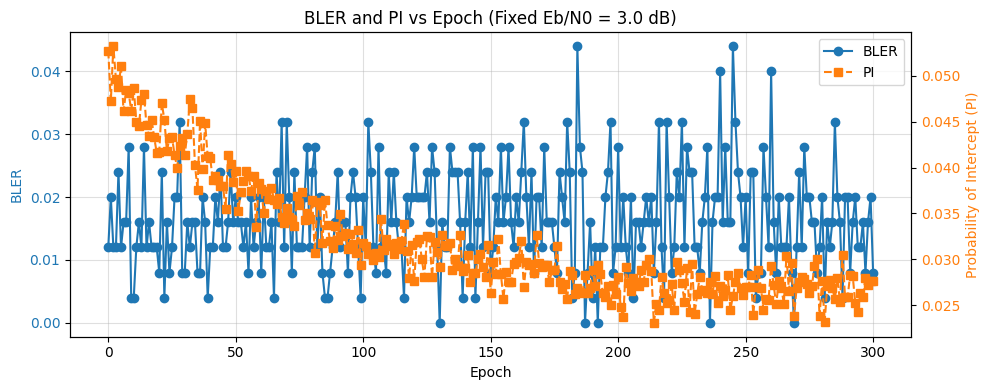

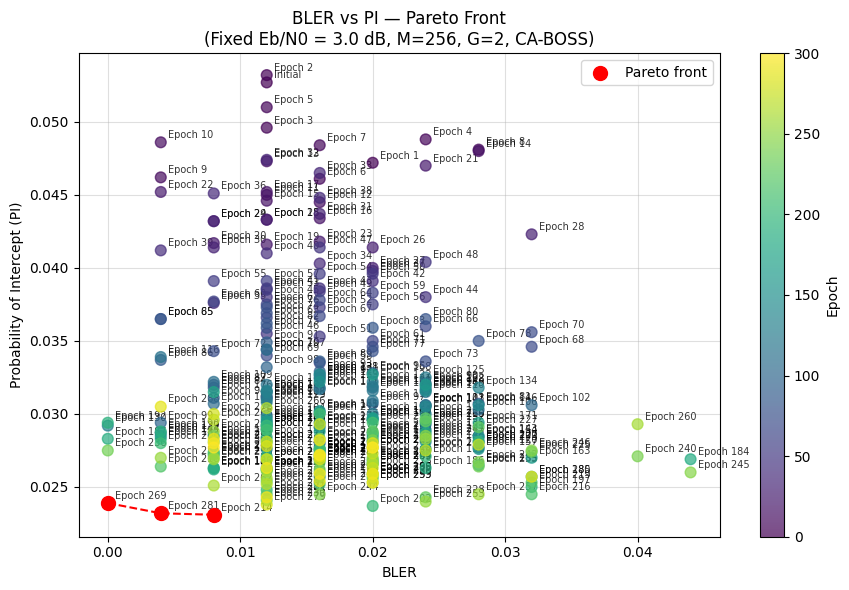


Best encoder by BLER+PI sum: Epoch 269 (BLER=0.0000, PI=0.0239)
BEST_ENCODER set to epoch 269.


In [ ]:
#=============================================================================================
#                            Pareto Simulation: BLER vs PI
#=============================================================================================

def compute_pi(encoder, U_waves_np, U_wind_np,
               avg_psd_waves, avg_psd_wind,
               threshold_waves, threshold_wind,
               n_trials=10000):
    detected = 0
    B_0 = int(np.floor(np.log2(encoder.G)))

    for _ in range(n_trials):
        bits = np.random.randint(0, 2, encoder.B).astype(np.float32)
        c, g, _ = encoder.encode(bits)

        psd_cw      = np.abs(np.fft.fft(c)) ** 2
        psd_cw      = np.fft.fftshift(psd_cw)
        psd_cw_norm = psd_cw / (psd_cw.sum() + 1e-8)

        if g == 0:
            psd_ref   = avg_psd_waves / (avg_psd_waves.sum() + 1e-8)
            threshold = threshold_waves
        else:
            psd_ref   = avg_psd_wind / (avg_psd_wind.sum() + 1e-8)
            threshold = threshold_wind

        dist = np.sqrt(np.sum((psd_cw_norm - psd_ref) ** 2))
        if dist > threshold:
            detected += 1

    return detected / n_trials


def simulate_bler_fixed_snr(encoder, ebno_db, polynomial, B_info,
                             batch_size=250, list_size=4):
    rate   = encoder.B / encoder.M
    Es     = encoder.K / encoder.M
    sigma2 = Es / (2 * rate * 10 ** (ebno_db / 10))

    decoder = BOSSDecoderStandalone(
        encoder, sigma2_v=sigma2,
        list_size=list_size, crc_poly=polynomial
    )

    block_errors  = 0
    bits_batch    = np.random.randint(0, 2, (batch_size, B_info))
    bits_with_crc = np.array([
        crc_encode(bits_batch[i], polynomial)
        for i in range(batch_size)
    ])

    c_batch, _, _ = encoder.encode(bits_with_crc)
    noise_batch   = np.random.normal(0, np.sqrt(sigma2),
                                     c_batch.shape).astype(np.float32)
    y_batch       = c_batch + noise_batch

    bits_hat_raw, _, _ = decoder.decode(y_batch)
    bits_hat_batch = np.array([
        b[:encoder.B] if len(b) >= encoder.B
        else np.concatenate([b, np.zeros(encoder.B - len(b), dtype=np.int32)])
        for b in bits_hat_raw
    ])

    for i in range(batch_size):
        valid, bits_hat = crc_check(bits_hat_batch[i], polynomial)
        if not valid or not np.array_equal(bits_batch[i], bits_hat):
            block_errors += 1

    return block_errors / batch_size


# ── Run simulations ───────────────────────────────────────────────────────────
print(f"Running Pareto simulations at fixed Eb/N0 = {EBNO_FIXED} dB...")
print("=" * 60)

pareto_results = []

for epoch, enc, U_waves_np, U_wind_np in encoders:
    label = "Initial" if epoch == 0 else f"Epoch {epoch}"

    bler = simulate_bler_fixed_snr(
        enc, EBNO_FIXED, CRC_POLY, B_info,
        batch_size=250, list_size=LIST_SIZE
    )
    pi = compute_pi(
        enc, U_waves_np, U_wind_np,
        avg_psd_waves, avg_psd_wind,
        THRESHOLD_WAVES, THRESHOLD_WIND,
        n_trials=10000
    )

    pareto_results.append({
        'epoch': epoch, 'label': label,
        'bler': bler, 'pi': pi
    })
    print(f"[{label:10s}] BLER = {bler:.4f}  |  PI = {pi:.4f}")


# ── Plot 1: BLER and PI vs Epoch ──────────────────────────────────────────────
epochs_p = [r['epoch'] for r in pareto_results]
blers_p  = [r['bler']  for r in pareto_results]
pis_p    = [r['pi']    for r in pareto_results]

fig, ax1 = plt.subplots(figsize=(10, 4))

color_bler = 'tab:blue'
color_pi   = 'tab:orange'

ax1.set_xlabel('Epoch')
ax1.set_ylabel('BLER', color=color_bler)
ax1.plot(epochs_p, blers_p, marker='o', color=color_bler,
         lw=1.5, label='BLER')
ax1.tick_params(axis='y', labelcolor=color_bler)
ax1.grid(True, alpha=0.4)

ax2 = ax1.twinx()   # share x axis, separate y axis
ax2.set_ylabel('Probability of Intercept (PI)', color=color_pi)
ax2.plot(epochs_p, pis_p, marker='s', color=color_pi,
         lw=1.5, linestyle='--', label='PI')
ax2.tick_params(axis='y', labelcolor=color_pi)

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.title(f'BLER and PI vs Epoch (Fixed Eb/N0 = {EBNO_FIXED} dB)')
plt.tight_layout()
plt.show()


# ── Plot 2: Pareto scatter with Pareto front highlighted ──────────────────────
# Compute Pareto front: point i is non-dominated if no other point j
# has both lower BLER and lower PI simultaneously
blers_arr = np.array(blers_p)
pis_arr   = np.array(pis_p)

pareto_mask = []
for i in range(len(blers_arr)):
    dominated = any(
        (blers_arr[j] <= blers_arr[i] and pis_arr[j] <= pis_arr[i] and
         (blers_arr[j] < blers_arr[i]  or  pis_arr[j] < pis_arr[i]))
        for j in range(len(blers_arr))
    )
    pareto_mask.append(not dominated)
pareto_mask = np.array(pareto_mask)

plt.figure(figsize=(9, 6))

# All points colored by epoch
sc = plt.scatter(blers_arr, pis_arr, c=epochs_p, cmap='viridis',
                 s=60, zorder=4, alpha=0.7)
plt.colorbar(sc, label='Epoch')

# Pareto front points in red
plt.scatter(blers_arr[pareto_mask], pis_arr[pareto_mask],
            c='red', s=100, zorder=5, label='Pareto front')

# Connect Pareto front points with a line (sorted by BLER)
pf_sorted = sorted(zip(blers_arr[pareto_mask], pis_arr[pareto_mask]))
if len(pf_sorted) > 1:
    plt.plot([p[0] for p in pf_sorted],
             [p[1] for p in pf_sorted],
             'r--', lw=1.5)

# Annotate all points
for r in pareto_results:
    plt.annotate(r['label'],
                 (r['bler'], r['pi']),
                 textcoords='offset points',
                 xytext=(5, 3), fontsize=7, alpha=0.8)

plt.xlabel('BLER')
plt.ylabel('Probability of Intercept (PI)')
plt.title(f'BLER vs PI — Pareto Front\n'
          f'(Fixed Eb/N0 = {EBNO_FIXED} dB, M=256, G=2, CA-BOSS)')
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()


# ── Best encoder selection ────────────────────────────────────────────────────
scores   = [r['bler'] + r['pi'] for r in pareto_results]
best_idx = int(np.argmin(scores))
best_result = pareto_results[best_idx]

print(f"\nBest encoder by BLER+PI sum: {best_result['label']} "
      f"(BLER={best_result['bler']:.4f}, PI={best_result['pi']:.4f})")

BEST_EPOCH = best_result['epoch']

# Look up encoder by epoch number, not by index
BEST_ENCODER = None
for epoch, enc, _, _ in encoders:
    if epoch == BEST_EPOCH:
        BEST_ENCODER = enc
        break

assert BEST_ENCODER is not None, f"Encoder for epoch {BEST_EPOCH} not found in encoders list"
print(f"BEST_ENCODER set to epoch {BEST_EPOCH}.")

Pareto front 점 수: 3
Best encoder (Pareto 내 정규화 거리): Epoch 281 (BLER=0.0040, PI=0.0232)
BEST_ENCODER set to epoch 281.

Listening to Waves codewords (sr=1024 Hz)


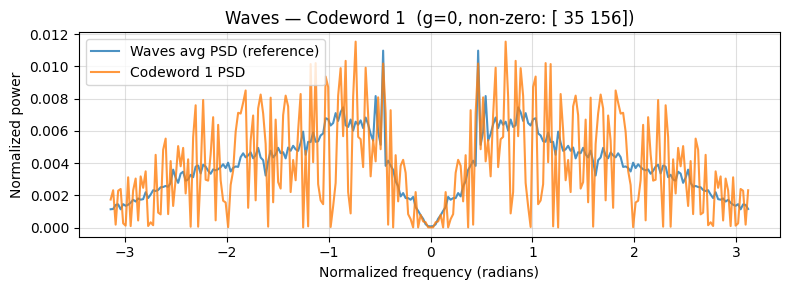

  Codeword 1 (g=0, non-zero indices: [ 35 156]):


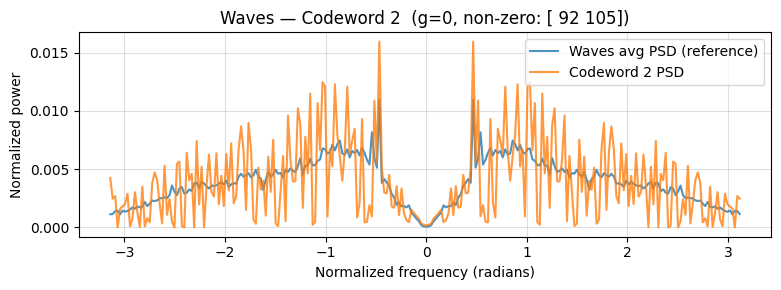

  Codeword 2 (g=0, non-zero indices: [ 92 105]):


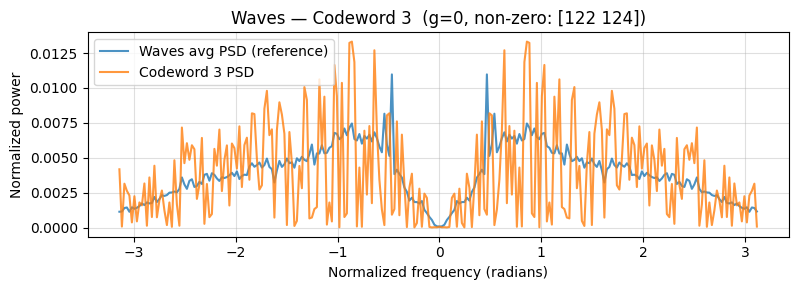

  Codeword 3 (g=0, non-zero indices: [122 124]):


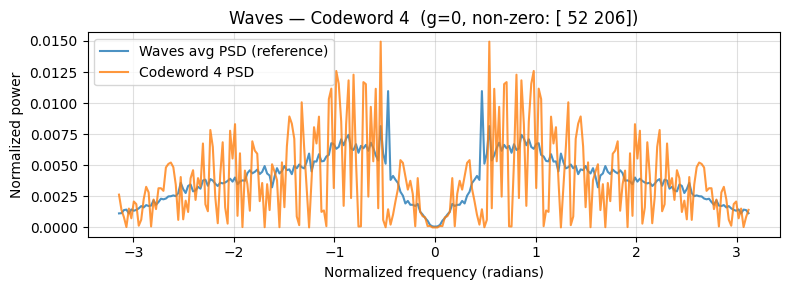

  Codeword 4 (g=0, non-zero indices: [ 52 206]):



  Concatenation of 4 codewords (4 × 0.25s = 1.00s total):



Listening to Wind codewords (sr=1024 Hz)


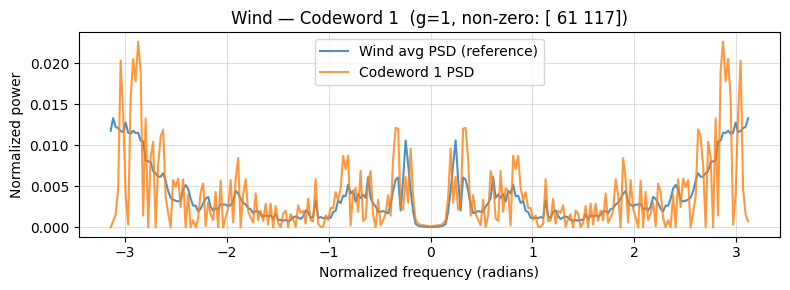

  Codeword 1 (g=1, non-zero indices: [ 61 117]):


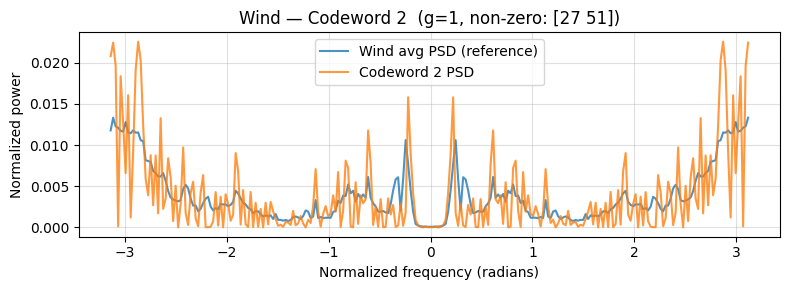

  Codeword 2 (g=1, non-zero indices: [27 51]):


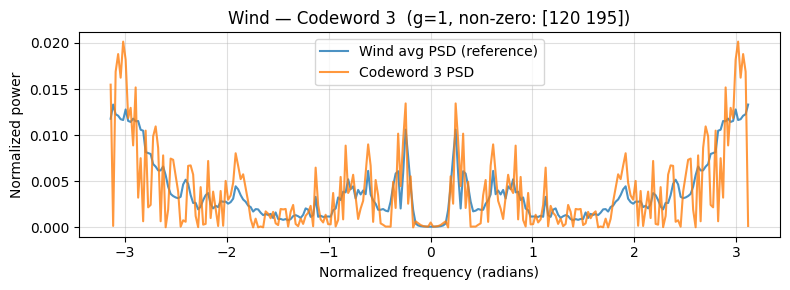

  Codeword 3 (g=1, non-zero indices: [120 195]):


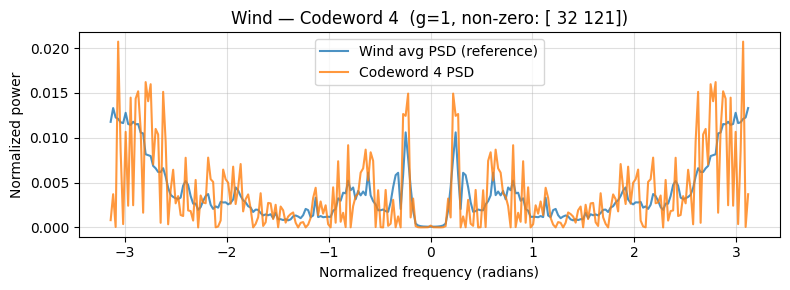

  Codeword 4 (g=1, non-zero indices: [ 32 121]):



  Concatenation of 4 codewords (4 × 0.25s = 1.00s total):


In [ ]:
# Pareto front 먼저 추출
bler_arr = np.array([r['bler'] for r in pareto_results])
pi_arr   = np.array([r['pi']   for r in pareto_results])

pareto_mask = []
for i in range(len(bler_arr)):
    dominated = any(
        (bler_arr[j] <= bler_arr[i] and pi_arr[j] <= pi_arr[i] and
         (bler_arr[j] < bler_arr[i] or pi_arr[j] < pi_arr[i]))
        for j in range(len(bler_arr))
    )
    pareto_mask.append(not dominated)
pareto_mask = np.array(pareto_mask)

# Pareto front 내에서만 정규화
pf_bler = bler_arr[pareto_mask]
pf_pi   = pi_arr[pareto_mask]
pf_results = [r for r, m in zip(pareto_results, pareto_mask) if m]

bler_n = (pf_bler - pf_bler.min()) / (pf_bler.max() - pf_bler.min() + 1e-8)
pi_n   = (pf_pi   - pf_pi.min())   / (pf_pi.max()   - pf_pi.min()   + 1e-8)

scores   = np.sqrt(bler_n**2 + pi_n**2)
best_idx = int(np.argmin(scores))
best_result = pf_results[best_idx]

print(f"Pareto front 점 수: {pareto_mask.sum()}")
print(f"Best encoder (Pareto 내 정규화 거리): {best_result['label']} "
      f"(BLER={best_result['bler']:.4f}, PI={best_result['pi']:.4f})")

BEST_EPOCH = best_result['epoch']
BEST_ENCODER = None
for epoch, enc, _, _ in encoders:
    if epoch == BEST_EPOCH:
        BEST_ENCODER = enc
        break
print(f"BEST_ENCODER set to epoch {BEST_EPOCH}.")

listen_to_codewords(BEST_ENCODER, "Waves", SR, avg_psd_waves)
listen_to_codewords(BEST_ENCODER, "Wind",  SR, avg_psd_wind)


[Orthogonality]
  [Original waves] ortho_loss = 2.07e-03
  [Original wind ] ortho_loss = 3.73e-03
  [QR-fixed waves] ortho_loss = 5.06e-18
  [QR-fixed wind ] ortho_loss = 5.03e-18

B_total=16, B_info=13

── Original BLER ─────────────────────────────────
[CA-BOSS] Eb/N0 = -4.0 dB  |  BLER = 0.8240  (412/500)
[CA-BOSS] Eb/N0 = -2.0 dB  |  BLER = 0.5780  (289/500)
[CA-BOSS] Eb/N0 = 0.0 dB  |  BLER = 0.2660  (133/500)
[CA-BOSS] Eb/N0 = 2.0 dB  |  BLER = 0.0640  (128/2000)
[CA-BOSS] Eb/N0 = 4.0 dB  |  BLER = 0.0043  (100/23000)
[CA-BOSS] Eb/N0 = 6.0 dB  |  BLER = 0.0001  (7/50000)

── QR-fixed BLER ─────────────────────────────────
[CA-BOSS] Eb/N0 = -4.0 dB  |  BLER = 0.7560  (378/500)
[CA-BOSS] Eb/N0 = -2.0 dB  |  BLER = 0.4920  (246/500)
[CA-BOSS] Eb/N0 = 0.0 dB  |  BLER = 0.2000  (200/1000)
[CA-BOSS] Eb/N0 = 2.0 dB  |  BLER = 0.0314  (110/3500)
[CA-BOSS] Eb/N0 = 4.0 dB  |  BLER = 0.0008  (41/50000)
[CA-BOSS] Eb/N0 = 6.0 dB  |  BLER = 0.0000  (0/50000)

[PI Results]
  Original — waves: 0

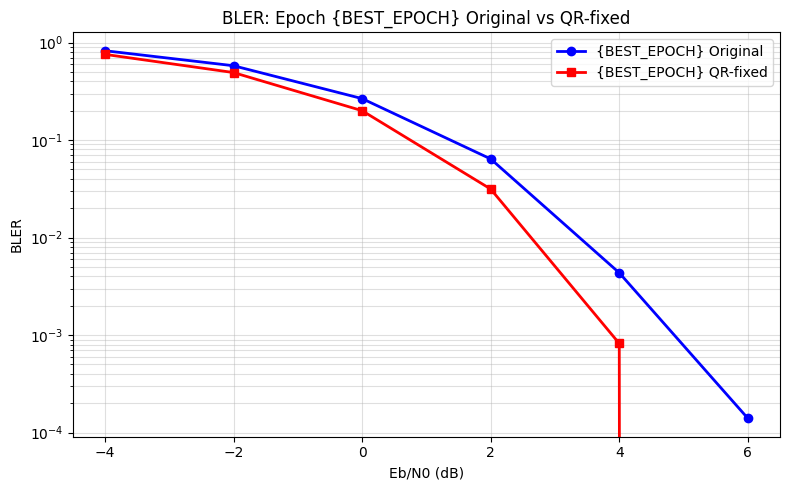

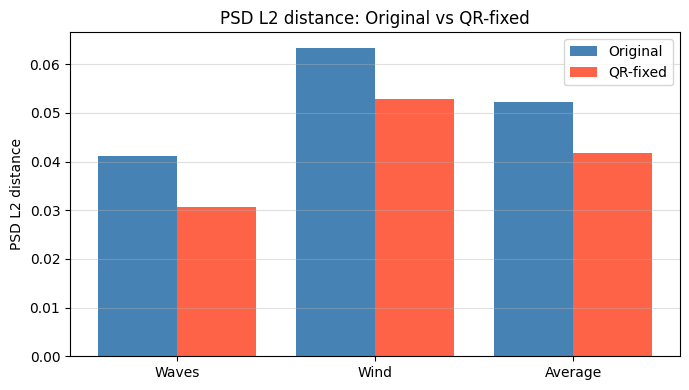


Listening to Waves [Original] codewords (sr=1024 Hz)


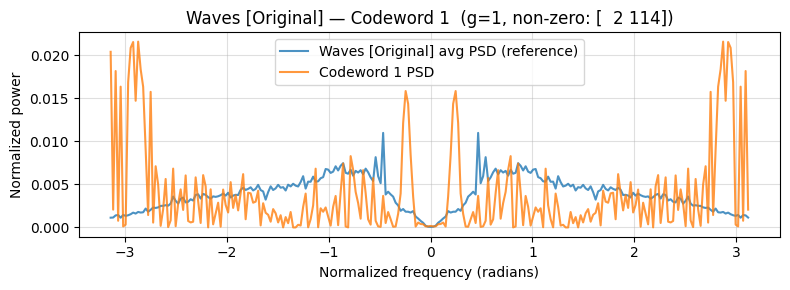

  Codeword 1 (g=1, non-zero indices: [  2 114]):


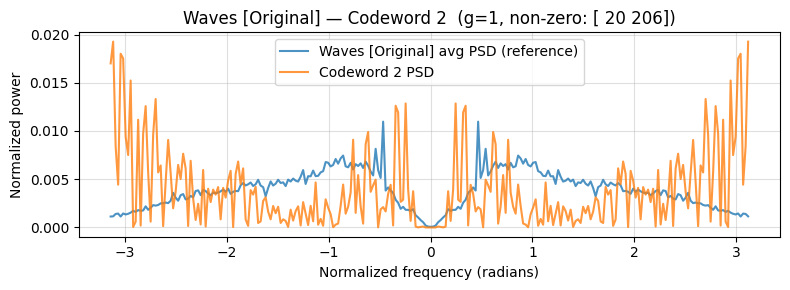

  Codeword 2 (g=1, non-zero indices: [ 20 206]):


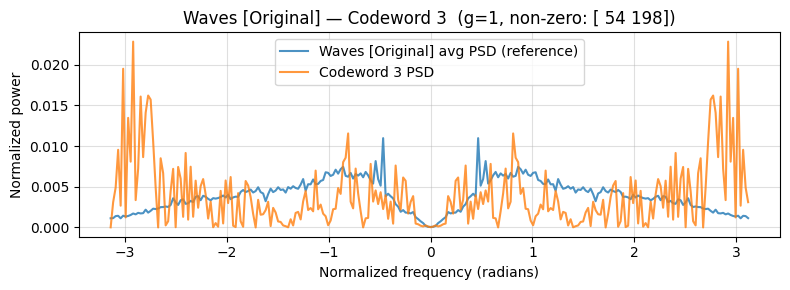

  Codeword 3 (g=1, non-zero indices: [ 54 198]):


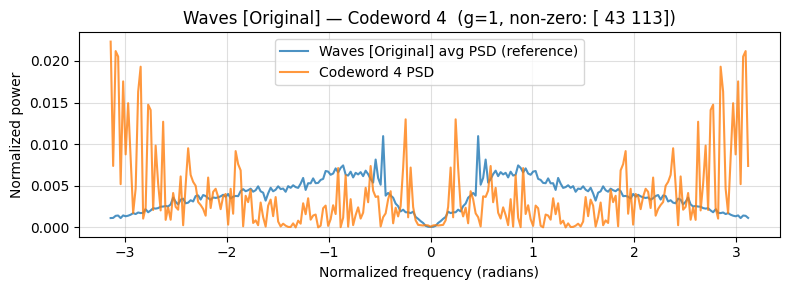

  Codeword 4 (g=1, non-zero indices: [ 43 113]):



  Concatenation of 4 codewords (4 × 0.25s = 1.00s total):



Listening to Waves [QR-fixed] codewords (sr=1024 Hz)


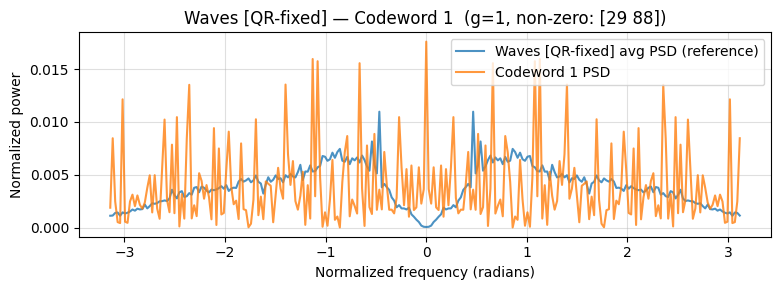

  Codeword 1 (g=1, non-zero indices: [29 88]):


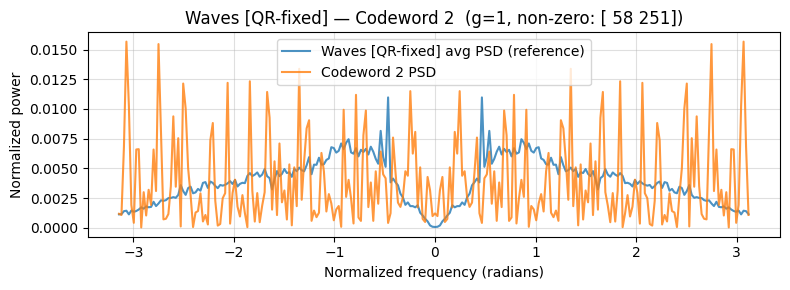

  Codeword 2 (g=1, non-zero indices: [ 58 251]):


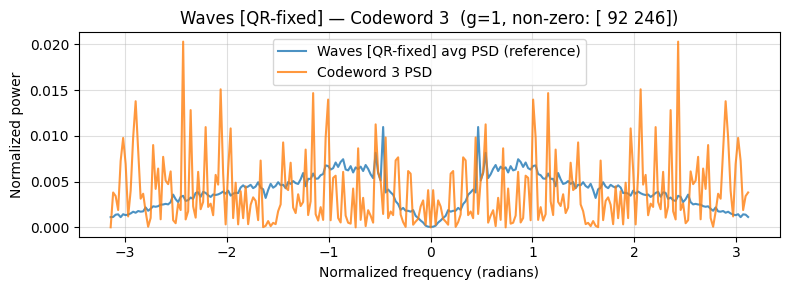

  Codeword 3 (g=1, non-zero indices: [ 92 246]):


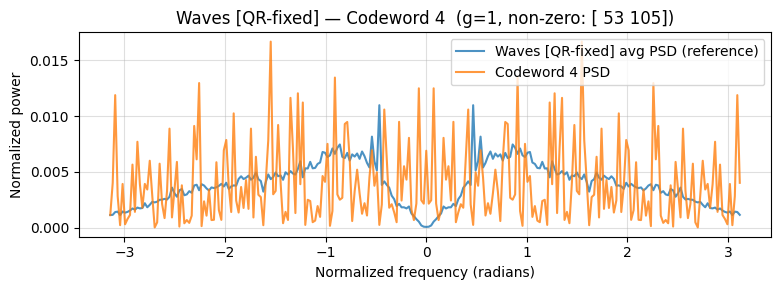

  Codeword 4 (g=1, non-zero indices: [ 53 105]):



  Concatenation of 4 codewords (4 × 0.25s = 1.00s total):



Listening to Wind  [Original] codewords (sr=1024 Hz)


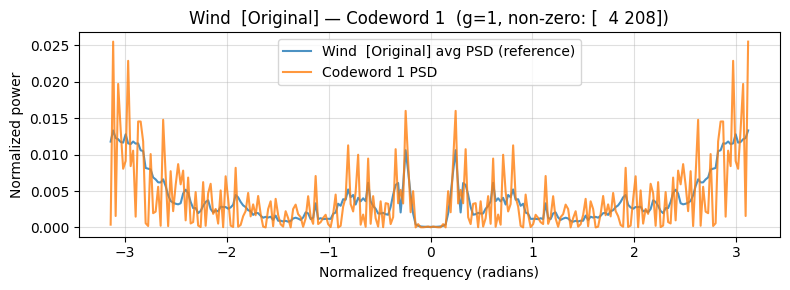

  Codeword 1 (g=1, non-zero indices: [  4 208]):


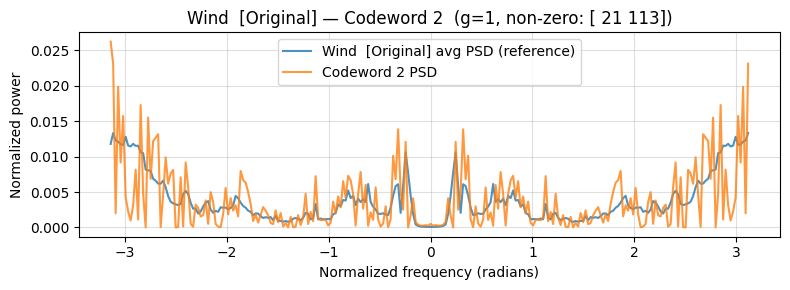

  Codeword 2 (g=1, non-zero indices: [ 21 113]):


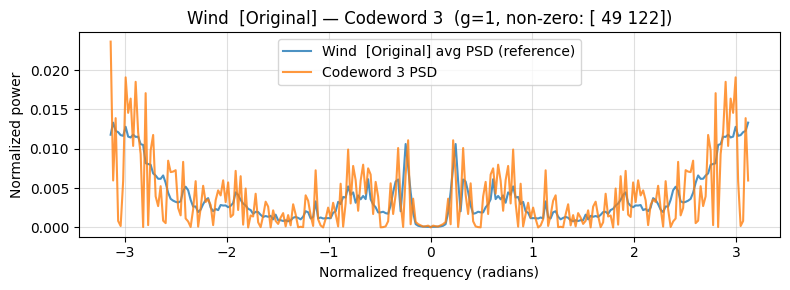

  Codeword 3 (g=1, non-zero indices: [ 49 122]):


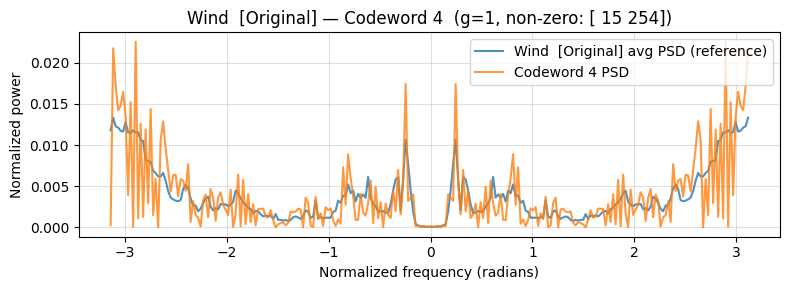

  Codeword 4 (g=1, non-zero indices: [ 15 254]):



  Concatenation of 4 codewords (4 × 0.25s = 1.00s total):



Listening to Wind  [QR-fixed] codewords (sr=1024 Hz)


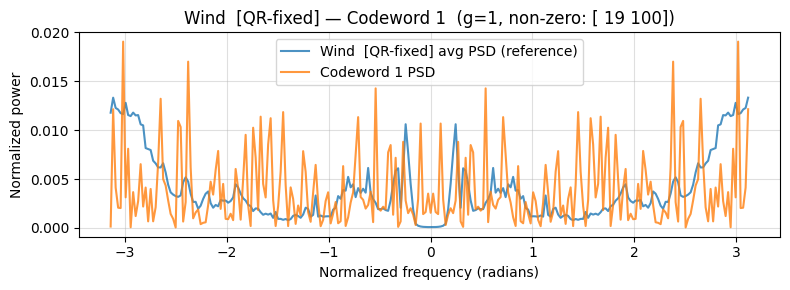

  Codeword 1 (g=1, non-zero indices: [ 19 100]):


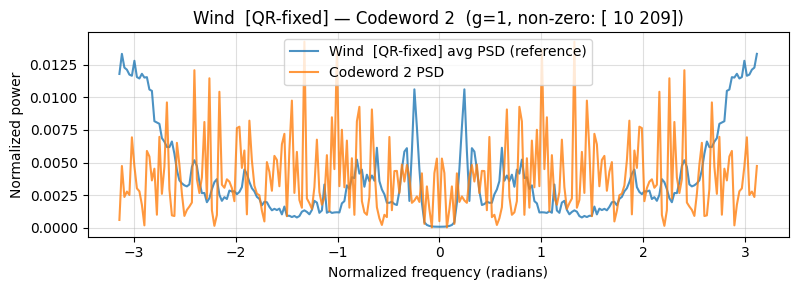

  Codeword 2 (g=1, non-zero indices: [ 10 209]):


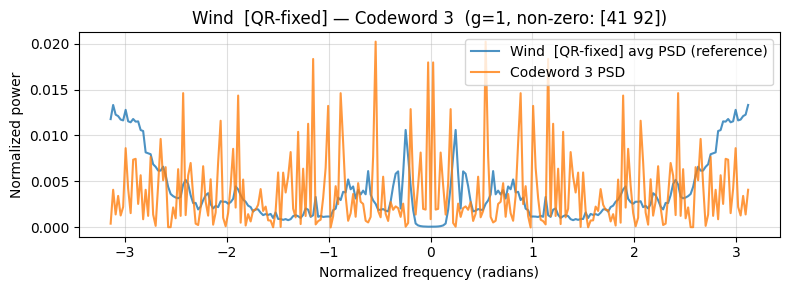

  Codeword 3 (g=1, non-zero indices: [41 92]):


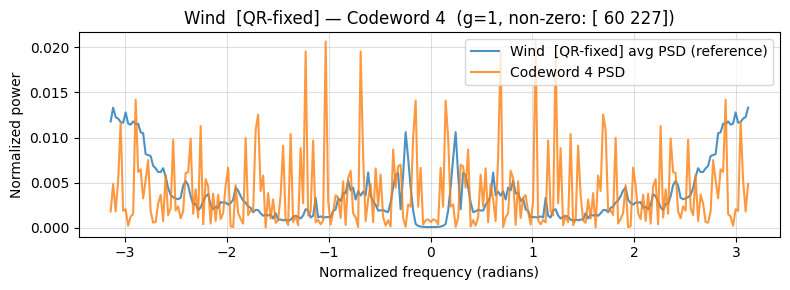

  Codeword 4 (g=1, non-zero indices: [ 60 227]):



  Concatenation of 4 codewords (4 × 0.25s = 1.00s total):


In [ ]:
#=============================================================
# Best encoder: Original vs QR-corrected (BLER + PI)
#=============================================================
import numpy as np
import matplotlib.pyplot as plt

# ── 1. QR 보정 ────────────────────────────────────────────
def qr_orthogonalize(U_np):
    Q, _ = np.linalg.qr(U_np.T)
    return Q.T.astype(np.float32)

U_waves_orig = BEST_ENCODER.A_list[0]
U_wind_orig  = BEST_ENCODER.A_list[1]
U_waves_qr   = qr_orthogonalize(U_waves_orig)
U_wind_qr    = qr_orthogonalize(U_wind_orig)

def check_ortho(U, name):
    G = U.astype(np.float64) @ U.astype(np.float64).T
    loss = np.mean((G - np.eye(len(G)))**2)
    print(f"  [{name}] ortho_loss = {loss:.2e}")

print("[Orthogonality]")
check_ortho(U_waves_orig, "Original waves")
check_ortho(U_wind_orig,  "Original wind ")
check_ortho(U_waves_qr,   "QR-fixed waves")
check_ortho(U_wind_qr,    "QR-fixed wind ")

# ── 2. 인코더 생성 ────────────────────────────────────────
encoder_orig = BOSSEncoderStandalone(
    M=256, G=2, L=2, sparsity_levels=[1, 1], alphabets=[[1.0], [-1.0]],
    A_list=[U_waves_orig, U_wind_orig]
)
encoder_qr = BOSSEncoderStandalone(
    M=256, G=2, L=2, sparsity_levels=[1, 1], alphabets=[[1.0], [-1.0]],
    A_list=[U_waves_qr, U_wind_qr]
)

_CRC_POLY = [1, 0, 1, 1]
_B_info   = encoder_orig.B - (len(_CRC_POLY) - 1)
print(f"\nB_total={encoder_orig.B}, B_info={_B_info}")

# ── 3. BLER 비교 ──────────────────────────────────────────
EBNO_RANGE = list(range(-4, 8, 2))

print("\n── Original BLER ─────────────────────────────────")
blers_orig = simulate_bler_ca_boss(encoder_orig, EBNO_RANGE, _CRC_POLY, _B_info,
                                   batch_size=500, num_target_block_errors=100)
print("\n── QR-fixed BLER ─────────────────────────────────")
blers_qr   = simulate_bler_ca_boss(encoder_qr,   EBNO_RANGE, _CRC_POLY, _B_info,
                                   batch_size=500, num_target_block_errors=100)

# ── 4. PI 계산 ────────────────────────────────────────────
def compute_psd_distance(enc, avg_psd_ref, n_cw=300):
    psds = []
    rng  = np.random.default_rng(42)
    M    = avg_psd_ref.shape[0]
    for _ in range(n_cw):
        bits = rng.integers(0, 2, size=(1, enc.B)).astype(np.float32)
        c, _, _ = enc.encode(bits)
        c_np = np.array(c).squeeze().astype(np.float64)
        psd  = np.abs(np.fft.fft(c_np, n=M)) ** 2
        psd /= psd.sum() + 1e-12
        psds.append(psd)
    avg_cw = np.mean(psds, axis=0)
    ref_n  = avg_psd_ref / (avg_psd_ref.sum() + 1e-12)
    return float(np.linalg.norm(avg_cw - ref_n))

pi_orig_w = compute_psd_distance(encoder_orig, avg_psd_waves)
pi_orig_n = compute_psd_distance(encoder_orig, avg_psd_wind)
pi_qr_w   = compute_psd_distance(encoder_qr,   avg_psd_waves)
pi_qr_n   = compute_psd_distance(encoder_qr,   avg_psd_wind)

print(f"\n[PI Results]")
print(f"  Original — waves: {pi_orig_w:.4f}, wind: {pi_orig_n:.4f}, avg: {(pi_orig_w+pi_orig_n)/2:.4f}")
print(f"  QR-fixed — waves: {pi_qr_w:.4f},  wind: {pi_qr_n:.4f},  avg: {(pi_qr_w+pi_qr_n)/2:.4f}")

# ── 5. BLER 플롯 ──────────────────────────────────────────
plt.figure(figsize=(8, 5))
plt.semilogy(EBNO_RANGE, blers_orig, 'b-o', lw=2, ms=6, label='{BEST_EPOCH} Original')
plt.semilogy(EBNO_RANGE, blers_qr,   'r-s', lw=2, ms=6, label='{BEST_EPOCH} QR-fixed')
plt.xlabel('Eb/N0 (dB)'); plt.ylabel('BLER')
plt.title('BLER: Epoch {BEST_EPOCH} Original vs QR-fixed')
plt.legend(); plt.grid(True, which='both', alpha=0.4)
plt.tight_layout(); plt.show()

# ── 6. PI 바차트 ──────────────────────────────────────────
labels   = ['Waves', 'Wind', 'Average']
pi_orig_vals = [pi_orig_w, pi_orig_n, (pi_orig_w + pi_orig_n) / 2]
pi_qr_vals   = [pi_qr_w,   pi_qr_n,   (pi_qr_w   + pi_qr_n)   / 2]

x = np.arange(len(labels))
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(x - 0.2, pi_orig_vals, 0.4, label='Original', color='steelblue')
ax.bar(x + 0.2, pi_qr_vals,   0.4, label='QR-fixed', color='tomato')
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel('PSD L2 distance'); ax.set_title('PSD L2 distance: Original vs QR-fixed')
ax.legend(); ax.grid(axis='y', alpha=0.4)
plt.tight_layout(); plt.show()

# ── 7. PSD 플롯 ───────────────────────────────────────────
listen_to_codewords(encoder_orig, "Waves [Original]", SR, avg_psd_waves)
listen_to_codewords(encoder_qr,   "Waves [QR-fixed]", SR, avg_psd_waves)
listen_to_codewords(encoder_orig, "Wind  [Original]", SR, avg_psd_wind)
listen_to_codewords(encoder_qr,   "Wind  [QR-fixed]", SR, avg_psd_wind)


In [ ]:
#=============================================================================================
# Export trained BOSS matrices
#=============================================================================================
A_stack = np.stack(BEST_ENCODER.A_list, axis=0)  # shape (G, M, M)

np.savez(
    "boss_capstone_matrices.npz",
    A=A_stack
)

print("Saved:", A_stack.shape)

from google.colab import files

files.download("boss_capstone_matrices.npz")

Saved: (2, 256, 256)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>